# STEP 1: Label Engineering

Tahap pertama dalam pipeline POSEIDON adalah memberikan identitas label kepada setiap deteksi kapal berbasis SAR (Synthetic Aperture Radar) di wilayah WPP 711 (Laut Natuna Utara dan sekitarnya). Proses pelabelan menghasilkan tiga kategori sebagai berikut.

- **Label P (Positive, Confirmed IUU)**: Deteksi SAR yang berhasil dicocokkan dengan kejadian penangkapan kapal ikan ilegal (seizure) oleh Bakamla atau instansi terkait.
- **Label RN (Reliable Negative, Kapal Legal)**: Kapal niaga non-fishing (cargo, tanker, bunker, passenger) dengan sinyal AIS aktif dan fishing score rendah.
- **Label U (Unlabeled, Status Tidak Diketahui)**: Data sisa yang tidak termasuk P maupun RN, menjadi populasi unlabeled dalam kerangka PU Learning.

In [1]:
import pandas as pd
import numpy as np
import zipfile
import gdown
import os
import time
import gc
from scipy.stats import chi2_contingency, ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [2]:
file_id = "1Hi05v9z0o397NGZer0YxcEwISpNzrne9"
zip_file = "POSEIDON_WPP711_complete.zip"

if not os.path.exists(zip_file):
    gdown.download(id=file_id, output=zip_file, quiet=False)

if os.path.exists(zip_file):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('.')

Downloading...
From (original): https://drive.google.com/uc?id=1Hi05v9z0o397NGZer0YxcEwISpNzrne9
From (redirected): https://drive.google.com/uc?id=1Hi05v9z0o397NGZer0YxcEwISpNzrne9&confirm=t&uuid=cf15ae69-6ed9-4214-9544-8ff2de889078
To: /content/POSEIDON_WPP711_complete.zip
100%|██████████| 29.1M/29.1M [00:01<00:00, 20.5MB/s]


In [3]:
SAR_FILE_ID = "1k-ePLPCFP3lfHTt_0sGoVSe-zvCGIfX1"
SEIZURE_ID = "11nifviDBWXHzss3pdvZwmANNbFz2kSvi"

SAR_PATH = "/content/POSEIDON_complete.csv"
SEIZURE_PATH = "/content/POSEIDON_WPP711_seizures_with_length.csv"

if not os.path.exists(SAR_PATH) and os.path.exists("POSEIDON_complete.csv"):
    SAR_PATH = "POSEIDON_complete.csv"

if not os.path.exists(SEIZURE_PATH) and os.path.exists("POSEIDON_WPP711_seizures_with_length (1).csv"):
    SEIZURE_PATH = "POSEIDON_WPP711_seizures_with_length (1).csv"
elif not os.path.exists(SEIZURE_PATH) and os.path.exists("POSEIDON_WPP711_seizures_with_length.csv"):
    SEIZURE_PATH = "POSEIDON_WPP711_seizures_with_length.csv"

if not os.path.exists(SAR_PATH):
    gdown.download(id=SAR_FILE_ID, output=SAR_PATH, quiet=False)

if not os.path.exists(SEIZURE_PATH):
    gdown.download(id=SEIZURE_ID, output=SEIZURE_PATH, quiet=False)

for path, name in [(SAR_PATH, "SAR"), (SEIZURE_PATH, "Seizure")]:
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"{name} terdownload: {path} ({size_kb:.1f} KB)")
    else:
        print(f"{name} GAGAL terdownload: {path}")

sar = pd.read_csv(SAR_PATH, low_memory=False)
seiz = pd.read_csv(SEIZURE_PATH)

sar["timestamp"] = pd.to_datetime(sar["timestamp"], utc=True)
seiz["date"] = pd.to_datetime(seiz["date"], utc=True)

if "row_id" not in sar.columns:
    sar = sar.reset_index().rename(columns={"index": "row_id"})

print(f"SAR rows: {len(sar)}")
print(f"Seizure events termuat: {len(seiz)}")

Downloading...
From: https://drive.google.com/uc?id=1k-ePLPCFP3lfHTt_0sGoVSe-zvCGIfX1
To: /content/POSEIDON_complete.csv
100%|██████████| 58.7M/58.7M [00:01<00:00, 55.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=11nifviDBWXHzss3pdvZwmANNbFz2kSvi
To: /content/POSEIDON_WPP711_seizures_with_length.csv
100%|██████████| 13.4k/13.4k [00:00<00:00, 36.8MB/s]


SAR terdownload: /content/POSEIDON_complete.csv (57299.8 KB)
Seizure terdownload: /content/POSEIDON_WPP711_seizures_with_length.csv (13.0 KB)
SAR rows: 151851
Seizure events termuat: 61


In [4]:
print(f"Total Seizure Events yang termuat dari CSV: {len(seiz)}")

Total Seizure Events yang termuat dari CSV: 61


## 1.1 Fungsi Haversine

Fungsi jarak geodesik Haversine digunakan untuk menghitung jarak permukaan bumi antara dua titik koordinat (latitude, longitude) dalam satuan kilometer. Fungsi ini menjadi dasar pencocokan spasial antara deteksi SAR dan lokasi penangkapan historis.

In [5]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    lat1r, lon1r, lat2r, lon2r = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2r - lat1r
    dlon = lon2r - lon1r
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

jarak_uji = haversine_km(4.0, 108.0, 4.1, 108.1)
print(f"Verifikasi Fungsi Haversine: Jarak antara (4.0, 108.0) dan (4.1, 108.1) = {jarak_uji:.4f} km")

Verifikasi Fungsi Haversine: Jarak antara (4.0, 108.0) dan (4.1, 108.1) = 15.7057 km


## 1.2 Matching Seizure Events ke Deteksi SAR (Label P)

Sistem matching menggunakan pendekatan Soft Clustering dan Global Allocation untuk menghindari bias First Come First Serve (FCFS).

1. **Filter Bounding Box WPP 711**: Seluruh data SAR dan seizure event disaring agar berada pada bounding box WPP 711 (102.90 111.05 BT, 4.16 LS 7.74 LU).

2. **Soft Clustering Top 20 Candidates**: Untuk setiap seizure event, dicari kandidat SAR dalam radius 30 km dan jendela waktu 12 hari hingga +1 hari. Skor spasial temporal 50:50 dihitung menggunakan normalisasi jarak dan selisih waktu.

3. **Global Optimal Allocation**: Setiap seizure memvalidasi kecocokan ukuran kapal. Jika satu deteksi SAR masuk ke Top 20 beberapa seizure sekaligus, dialokasikan ke seizure dengan kualitas match terbaik.

4. **Rekalkulasi dist_to_nearest_seizure_km (Leakage Free)**: Referensi penangkapan hanya dari tahun 2023 2024. Kapal berlabel P wajib mengecualikan titik penangkapannya sendiri (Leave One Out).

In [6]:
BBOX_LON_MIN, BBOX_LON_MAX = 102.90, 111.05
BBOX_LAT_MIN, BBOX_LAT_MAX = -4.16, 7.74

sar_in_bbox = sar['lon'].between(BBOX_LON_MIN, BBOX_LON_MAX) & sar['lat'].between(BBOX_LAT_MIN, BBOX_LAT_MAX)
sar_clean = sar[sar_in_bbox].copy().reset_index(drop=True)

seiz_in_bbox = seiz['lon'].between(BBOX_LON_MIN, BBOX_LON_MAX) & seiz['lat'].between(BBOX_LAT_MIN, BBOX_LAT_MAX)
seiz_clean = seiz[seiz_in_bbox].copy().reset_index(drop=True)

print(f"SAR awal: {len(sar)} baris -> Lolos Bounding Box WPP 711: {len(sar_clean)} baris")
print(f"Seizure awal: {len(seiz)} baris -> Lolos Bounding Box WPP 711: {len(seiz_clean)} baris")

TIME_WINDOW_MIN = pd.Timedelta(days=12)
TIME_WINDOW_MAX = pd.Timedelta(days=1)
SPATIAL_RADIUS_KM = 30.0

SAR awal: 151851 baris -> Lolos Bounding Box WPP 711: 151851 baris
Seizure awal: 61 baris -> Lolos Bounding Box WPP 711: 56 baris


In [7]:
seizure_candidates = {}

for idx_seiz, row_seiz in seiz_clean.iterrows():
    s_date = row_seiz['date']
    s_lat = row_seiz['lat']
    s_lon = row_seiz['lon']
    s_flag = str(row_seiz['vessel_flag'])
    s_length = row_seiz['length']

    min_time = s_date - TIME_WINDOW_MIN
    max_time = s_date + TIME_WINDOW_MAX
    time_mask = (sar_clean['timestamp'] >= min_time) & (sar_clean['timestamp'] <= max_time)
    candidates = sar_clean[time_mask].copy()
    if len(candidates) == 0:
        continue

    dists = haversine_km(candidates['lat'].values, candidates['lon'].values, s_lat, s_lon)
    candidates['dist_km'] = dists
    candidates = candidates[candidates['dist_km'] <= SPATIAL_RADIUS_KM]
    if len(candidates) == 0:
        continue

    if s_flag.lower() != 'indonesia':
        candidates = candidates[candidates['ais_matched'] == 0]
        if len(candidates) == 0:
            continue

    candidates['time_diff_days'] = (candidates['timestamp'] - s_date).abs().dt.total_seconds() / 86400.0
    norm_dist = candidates['dist_km'] / SPATIAL_RADIUS_KM
    norm_time = candidates['time_diff_days'] / 12.0
    candidates['st_score'] = 0.5 * norm_dist + 0.5 * norm_time

    candidates = candidates.sort_values(by='st_score').head(20).copy()
    candidates['st_rank'] = range(1, len(candidates) + 1)

    candidates['length_diff'] = (candidates['length_m'] - s_length).abs()
    candidates = candidates.sort_values(by=['length_diff', 'st_rank'])

    seizure_candidates[idx_seiz] = candidates

In [8]:
assigned_sar_to_seiz = {}
seiz_final_match = {}
unassigned_seizures = set(seizure_candidates.keys())

while unassigned_seizures:
    progress = False
    for s_idx in list(unassigned_seizures):
        cand_df = seizure_candidates[s_idx]
        for idx_cand, c_row in cand_df.iterrows():
            sar_idx = idx_cand
            c_len_diff = c_row['length_diff']
            c_st_rank = c_row['st_rank']
            c_st_score = c_row['st_score']

            if sar_idx not in assigned_sar_to_seiz:
                assigned_sar_to_seiz[sar_idx] = (s_idx, c_len_diff, c_st_rank, c_st_score)
                seiz_final_match[s_idx] = sar_idx
                unassigned_seizures.remove(s_idx)
                progress = True
                break
            else:
                ex_s_idx, ex_len_diff, ex_st_rank, ex_st_score = assigned_sar_to_seiz[sar_idx]
                is_better = (c_len_diff < ex_len_diff - 1e-4) or (abs(c_len_diff - ex_len_diff) <= 1e-4 and c_st_rank < ex_st_rank)
                if is_better:
                    assigned_sar_to_seiz[sar_idx] = (s_idx, c_len_diff, c_st_rank, c_st_score)
                    seiz_final_match[s_idx] = sar_idx
                    unassigned_seizures.remove(s_idx)
                    if ex_s_idx in seiz_final_match and seiz_final_match[ex_s_idx] == sar_idx:
                        del seiz_final_match[ex_s_idx]
                    unassigned_seizures.add(ex_s_idx)
                    progress = True
                    break

    if not progress:
        break

In [9]:
headers = ["Tanggal Seizure", "Bendera", "Koordinat Seizure", "Matched Row ID", "Jarak (km)", "Beda Hari", "Score (50:50)", "Rank ST", "Pred Length", "SAR Length", "Delta L (m)"]
print(f"{headers[0]:<15} | {headers[1]:<10} | {headers[2]:<18} | {headers[3]:<14} | {headers[4]:<10} | {headers[5]:<9} | {headers[6]:<13} | {headers[7]:<7} | {headers[8]:<11} | {headers[9]:<10} | {headers[10]:<11}")

sar_labeled = sar_clean.copy()
sar_labeled['label'] = 'U'

matched_sar_indices = set(seiz_final_match.values())

for s_idx, sar_idx in sorted(seiz_final_match.items()):
    row_seiz = seiz_clean.loc[s_idx]
    c_df = seizure_candidates[s_idx]
    best_row = c_df.loc[sar_idx]

    s_date_str = row_seiz['date'].strftime('%Y-%m-%d')
    s_flag = str(row_seiz['vessel_flag'])
    seiz_coord = f"({row_seiz['lat']:.2f}, {row_seiz['lon']:.2f})"
    matched_row_id = int(best_row['row_id'])
    dist_km = best_row['dist_km']
    time_diff_days = best_row['time_diff_days']
    st_score = best_row['st_score']
    st_rank = int(best_row['st_rank'])
    s_length = row_seiz['length']
    sar_len = best_row['length_m']
    len_diff = best_row['length_diff']

    print(f"{s_date_str:<15} | {s_flag:<10} | {seiz_coord:<18} | {matched_row_id:<14} | {dist_km:<10.2f} | {time_diff_days:<9.2f} | {st_score:<13.4f} | {st_rank:<7} | {s_length:<11.2f} | {sar_len:<10.2f} | {len_diff:<11.2f}")

sar_labeled.loc[list(matched_sar_indices), 'label'] = 'P'

Tanggal Seizure | Bendera    | Koordinat Seizure  | Matched Row ID | Jarak (km) | Beda Hari | Score (50:50) | Rank ST | Pred Length | SAR Length | Delta L (m)
2023-03-20      | Indonesia  | (-3.44, 106.53)    | 12995          | 12.02      | 0.06      | 0.2029        | 10      | 23.27       | 22.42      | 0.85       
2023-03-20      | Indonesia  | (-3.45, 106.55)    | 13038          | 19.00      | 0.06      | 0.3191        | 20      | 24.56       | 23.70      | 0.87       
2023-03-22      | Indonesia  | (2.69, 105.02)     | 11380          | 4.28       | 10.53     | 0.5101        | 15      | 16.19       | 17.61      | 1.42       
2023-03-22      | Indonesia  | (2.73, 104.99)     | 11610          | 8.12       | 10.53     | 0.5740        | 16      | 16.19       | 18.23      | 2.03       
2023-03-27      | Vietnam    | (2.89, 104.88)     | 12340          | 18.10      | 9.05      | 0.6787        | 5       | 22.88       | 22.13      | 0.75       
2023-03-29      | Indonesia  | (3.51, 109.97) 

In [10]:
print(f"Jumlah baris berlabel P (Confirmed IUU): {len(matched_sar_indices)}")

Jumlah baris berlabel P (Confirmed IUU): 43


In [11]:
seiz_ref_2023_2024 = seiz_clean[pd.to_datetime(seiz_clean['date']).dt.year <= 2024].copy()
seiz_ref_lats = np.radians(seiz_ref_2023_2024['lat'].values)[None, :]
seiz_ref_lons = np.radians(seiz_ref_2023_2024['lon'].values)[None, :]

sar_lats = np.radians(sar_labeled['lat'].values)[:, None]
sar_lons = np.radians(sar_labeled['lon'].values)[:, None]

dlat = seiz_ref_lats - sar_lats
dlon = seiz_ref_lons - sar_lons
a = np.sin(dlat / 2)**2 + np.cos(sar_lats) * np.cos(seiz_ref_lats) * np.sin(dlon / 2)**2
dists_matrix = 2 * 6371.0088 * np.arcsin(np.sqrt(a))

dists_sorted = np.sort(dists_matrix, axis=1)
is_p_arr = (sar_labeled['label'] == 'P').values

min_dists = np.where(
    is_p_arr | (dists_sorted[:, 0] < 0.05),
    np.where(dists_sorted.shape[1] > 1, dists_sorted[:, 1], -1.0),
    dists_sorted[:, 0]
)

sar_labeled['dist_to_nearest_seizure_km'] = np.round(min_dists, 4)

del dists_matrix, a, dlat, dlon, sar_lats, sar_lons, seiz_ref_lats, seiz_ref_lons
gc.collect()

18

## 1.3 Pelabelan Reliable Negative (Label RN)

Kriteria RN ditentukan berdasarkan kombinasi indikator yang secara domain maritim menunjukkan bahwa kapal tersebut bukan penangkap ikan ilegal.

- ais_matched = 1 (sinyal AIS aktif dan teridentifikasi)
- fishing_score < 0.1 (tidak menunjukkan pola operasi penangkapan ikan)
- ais_vessel_type termasuk dalam kategori niaga (cargo, bunker, carrier, passenger)

In [12]:
rn_vessel_types = ['cargo', 'bunker', 'carrier', 'passenger']

rn_mask = (
    (sar_labeled['ais_matched'] == 1) &
    (sar_labeled['fishing_score'] < 0.1) &
    (sar_labeled['ais_vessel_type'].isin(rn_vessel_types)) &
    (sar_labeled['label'] != 'P')
)

sar_labeled.loc[rn_mask, 'label'] = 'RN'

print(sar_labeled['label'].value_counts())

label
U     128374
RN     23434
P         43
Name: count, dtype: int64


In [13]:
p_rows = sar_labeled[sar_labeled['label'] == 'P']
print(p_rows[['row_id', 'ais_matched', 'matched_category', 'fishing_score', 'timestamp']])

        row_id  ais_matched matched_category  fishing_score  \
11380    11380            1             gear       0.960768   
11610    11610            0        unmatched       0.960768   
12340    12340            0        unmatched       0.960768   
12995    12995            0        unmatched       0.623242   
13038    13038            0        unmatched       0.505672   
14012    14012            0        unmatched       0.780267   
20145    20145            0        unmatched       0.960768   
20174    20174            1    seismicvessel       0.960768   
20235    20235            1            other       0.960768   
20254    20254            1            other       0.960768   
21838    21838            0        unmatched       0.678079   
23625    23625            1          fishing       0.610731   
37189    37189            0        unmatched       0.121981   
41012    41012            0        unmatched       0.080877   
41061    41061            1            other       0.03

## 1.4 Evaluasi dan Analisis Anomali Pasca Matching (Confidence Level Audit)

Setiap hasil matching dievaluasi melalui pengecekan kualitas tiga tahap: validasi fishing score, analisis selisih panjang kapal (Bakamla vs SAR/GFW), dan klasifikasi tingkat kepercayaan. Kapal yang menunjukkan anomali (fishing score rendah atau selisih panjang ekstrem) didemosi dari label P ke label U untuk menjaga integritas label training.

In [14]:
p_audit_list = []

for s_idx, sar_idx in sorted(seiz_final_match.items()):
    row_seiz = seiz_clean.loc[s_idx]
    c_df = seizure_candidates[s_idx]
    best_row = c_df.loc[sar_idx]

    s_date_str = row_seiz['date'].strftime('%Y-%m-%d')
    s_flag = str(row_seiz['vessel_flag'])
    matched_row_id = int(best_row['row_id'])
    dist_km = float(best_row['dist_km'])
    time_diff_days = float(best_row['time_diff_days'])
    st_score = float(best_row['st_score'])
    st_rank = int(best_row['st_rank'])
    s_length = float(row_seiz['length'])
    sar_len = float(best_row['length_m'])
    len_diff = float(best_row['length_diff'])
    f_score = float(best_row['fishing_score'])
    ais_matched = int(best_row['ais_matched'])

    is_anomaly = (f_score < 0.3) or (len_diff > 30.0)
    conf_level = 'Berpotensi Rawan (Anomali)' if is_anomaly else 'Berpotensi Sangat Aman'

    reasons = []
    if f_score < 0.3:
        reasons.append(f'Fishing Score Rendah ({f_score:.3f})')
    if len_diff > 30.0:
        reasons.append(f'Gap Panjang Ekstrem ({len_diff:.1f} m)')

    p_audit_list.append({
        'seiz_date': s_date_str,
        'flag': s_flag,
        'matched_row_id': matched_row_id,
        'dist_km': round(dist_km, 2),
        'days_diff': round(time_diff_days, 2),
        'st_rank': st_rank,
        'bakamla_len': round(s_length, 2),
        'gfw_sar_len': round(sar_len, 2),
        'len_diff': round(len_diff, 2),
        'fishing_score': round(f_score, 3),
        'ais_matched': ais_matched,
        'conf_level': conf_level,
        'anomali_note': '; '.join(reasons) if reasons else 'Normal'
    })

df_p_audit = pd.DataFrame(p_audit_list)

In [15]:
print(f'Validasi Fishing Score (Label P)')
print(f'  Rata-rata Fishing Score : {df_p_audit["fishing_score"].mean():.4f}')
print(f'  Median Fishing Score    : {df_p_audit["fishing_score"].median():.4f}')
print(f'  Rentang (Min, Max)      : {df_p_audit["fishing_score"].min():.4f}, {df_p_audit["fishing_score"].max():.4f}')

Validasi Fishing Score (Label P)
  Rata-rata Fishing Score : 0.6424
  Median Fishing Score    : 0.6490
  Rentang (Min, Max)      : 0.0130, 0.9610


In [16]:
print(f'Analisis Length Gap (Bakamla vs GFW/SAR)')
print(f'  Rata-rata Selisih Panjang : {df_p_audit["len_diff"].mean():.2f} meter')
print(f'  Median Selisih Panjang    : {df_p_audit["len_diff"].median():.2f} meter')
print(f'  Selisih Maksimum          : {df_p_audit["len_diff"].max():.2f} meter')

Analisis Length Gap (Bakamla vs GFW/SAR)
  Rata-rata Selisih Panjang : 10.41 meter
  Median Selisih Panjang    : 0.87 meter
  Selisih Maksimum          : 98.78 meter


In [17]:
print(f'Klasifikasi Confidence Level')
print(df_p_audit['conf_level'].value_counts())

Klasifikasi Confidence Level
conf_level
Berpotensi Sangat Aman        36
Berpotensi Rawan (Anomali)     7
Name: count, dtype: int64


In [18]:
print('Daftar Kapal Berpotensi Rawan (Anomali)')
df_rawan = df_p_audit[df_p_audit['conf_level'] == 'Berpotensi Rawan (Anomali)']
if len(df_rawan) > 0:
    print(df_rawan[['seiz_date', 'flag', 'matched_row_id', 'bakamla_len', 'gfw_sar_len', 'len_diff', 'fishing_score', 'anomali_note']].to_string(index=False))
else:
    print('Tidak ditemukan anomali')

Daftar Kapal Berpotensi Rawan (Anomali)
 seiz_date         flag  matched_row_id  bakamla_len  gfw_sar_len  len_diff  fishing_score                                               anomali_note
2023-09-13    Indonesia           37189        16.36        67.41     51.05          0.122 Fishing Score Rendah (0.122); Gap Panjang Ekstrem (51.1 m)
2023-10-05    Indonesia           41012        16.19        63.77     47.58          0.081 Fishing Score Rendah (0.081); Gap Panjang Ekstrem (47.6 m)
2023-10-05    Indonesia           41061        16.02        78.91     62.90          0.031 Fishing Score Rendah (0.031); Gap Panjang Ekstrem (62.9 m)
2024-02-28    Indonesia           57540        22.56       121.34     98.78          0.013 Fishing Score Rendah (0.013); Gap Panjang Ekstrem (98.8 m)
2024-10-09 Sierra Leone           85747        91.67       138.23     46.56          0.023 Fishing Score Rendah (0.023); Gap Panjang Ekstrem (46.6 m)
2024-10-09 Sierra Leone           85946        93.55       1

In [19]:
print('Daftar Kapal Berpotensi Sangat Aman')
df_aman = df_p_audit[df_p_audit['conf_level'] == 'Berpotensi Sangat Aman']
print(df_aman[['seiz_date', 'flag', 'matched_row_id', 'bakamla_len', 'gfw_sar_len', 'len_diff', 'fishing_score']].to_string(index=False))

Daftar Kapal Berpotensi Sangat Aman
 seiz_date      flag  matched_row_id  bakamla_len  gfw_sar_len  len_diff  fishing_score
2023-03-20 Indonesia           12995        23.27        22.42      0.85          0.623
2023-03-20 Indonesia           13038        24.56        23.70      0.87          0.506
2023-03-22 Indonesia           11380        16.19        17.61      1.42          0.961
2023-03-22 Indonesia           11610        16.19        18.23      2.03          0.961
2023-03-27   Vietnam           12340        22.88        22.13      0.75          0.961
2023-03-29 Indonesia           14012        21.15        18.97      2.18          0.780
2023-05-20 Indonesia           20235        16.36        15.57      0.79          0.961
2023-05-20 Indonesia           20254        16.19        15.75      0.45          0.961
2023-05-20 Indonesia           20174        16.36        16.81      0.45          0.961
2023-05-20 Indonesia           20145        16.36        15.99      0.37          0.

## 1.5 Penerapan Filter Strict (Pembersihan Label P Akhir)

Berdasarkan hasil Confidence Level Audit, kapal yang terklasifikasi sebagai anomali didemosi dari label P ke label U. Hanya kapal dengan tingkat kepercayaan tinggi yang dipertahankan sebagai label P untuk menjamin kualitas ground truth pada tahap PU Learning.

In [20]:
conf_col = 'Confidence Level' if 'Confidence Level' in df_p_audit.columns else 'conf_level'
id_col = 'Matched Row ID' if 'Matched Row ID' in df_p_audit.columns else 'matched_row_id'

strict_p_indices = set(df_p_audit[df_p_audit[conf_col] == 'Berpotensi Sangat Aman'][id_col].values)
rawan_indices = set(df_p_audit[df_p_audit[conf_col] == 'Berpotensi Rawan (Anomali)'][id_col].values)

sar_labeled['label'] = 'U'
sar_labeled.loc[rn_mask, 'label'] = 'RN'
sar_labeled.loc[sar_labeled['row_id'].isin(strict_p_indices), 'label'] = 'P'

print(f'Total Label P Terverifikasi Sangat Aman : {len(strict_p_indices)}')
print(f'Total Kapal Rawan Didemosi ke Label U   : {len(rawan_indices)}')
print(f'Total Label RN (Reliable Negative)      : {rn_mask.sum()}')
print(f'Distribusi Label Akhir untuk ML Training:')
print(sar_labeled['label'].value_counts())

Total Label P Terverifikasi Sangat Aman : 36
Total Kapal Rawan Didemosi ke Label U   : 7
Total Label RN (Reliable Negative)      : 23434
Distribusi Label Akhir untuk ML Training:
label
U     128381
RN     23434
P         36
Name: count, dtype: int64


In [21]:
seiz_ref_lats = np.radians(seiz_ref_2023_2024['lat'].values)[None, :]
seiz_ref_lons = np.radians(seiz_ref_2023_2024['lon'].values)[None, :]

sar_lats = np.radians(sar_labeled['lat'].values)[:, None]
sar_lons = np.radians(sar_labeled['lon'].values)[:, None]

dlat = seiz_ref_lats - sar_lats
dlon = seiz_ref_lons - sar_lons
a = np.sin(dlat / 2)**2 + np.cos(sar_lats) * np.cos(seiz_ref_lats) * np.sin(dlon / 2)**2
dists_matrix = 2 * 6371.0088 * np.arcsin(np.sqrt(a))

dists_sorted = np.sort(dists_matrix, axis=1)
is_p_arr = (sar_labeled['label'] == 'P').values

min_dists = np.where(
    is_p_arr | (dists_sorted[:, 0] < 0.05),
    np.where(dists_sorted.shape[1] > 1, dists_sorted[:, 1], -1.0),
    dists_sorted[:, 0]
)

sar_labeled['dist_to_nearest_seizure_km'] = np.round(min_dists, 4)

del dists_matrix, a, dlat, dlon, sar_lats, sar_lons, seiz_ref_lats, seiz_ref_lons
gc.collect()

print("dist_to_nearest_seizure_km direkalkulasi ulang menggunakan label final.")

dist_to_nearest_seizure_km direkalkulasi ulang menggunakan label final.


## 1.6 Exploratory Data Analysis

Analisis eksplorasi data dilakukan untuk memvalidasi distribusi fitur antar label (P, RN, U), mengidentifikasi pola spasial dan temporal, serta memastikan bahwa fitur yang digunakan dalam pemodelan memiliki daya pembeda yang signifikan secara statistik.

In [22]:
for feat in ['inside_mpa', 'ais_matched', 'vessel_redetection']:
    ct = pd.crosstab(sar_labeled['label'], sar_labeled[feat])
    chi2, pval, dof, exp = chi2_contingency(ct)
    print(feat)
    print(ct)
    print(f"proporsi di P: {sar_labeled.loc[sar_labeled['label']=='P', feat].value_counts(normalize=True).to_dict()}")
    print(f"proporsi total: {sar_labeled[feat].value_counts(normalize=True).to_dict()}")
    print(f"chi2={chi2:.3f}, p-value={pval:.6f}")
    print()

nd = sar_labeled['neighbor_dark_prev']
print("neighbor_dark_prev")
print(nd.value_counts(normalize=True).head(5))
print(f"proporsi nilai 0: {(nd == 0).mean()*100:.2f}%")
print(f"proporsi di P: {sar_labeled.loc[sar_labeled['label']=='P', 'neighbor_dark_prev'].value_counts(normalize=True).to_dict()}")
print(f"varians: {nd.var():.6f}")

print()
print(seiz_clean['vessel_flag'].value_counts())
non_id_flags = seiz_clean[seiz_clean['vessel_flag'].str.lower() != 'indonesia']
print(f"jumlah seizure berbendera asing: {len(non_id_flags)}")

print()
vr_summary = sar_labeled.groupby('label')['vessel_redetection'].value_counts(normalize=True)
print(vr_summary)

inside_mpa
inside_mpa       0     1
label                   
P               34     2
RN           22734   700
U           122074  6307
proporsi di P: {0: 0.9444444444444444, 1: 0.05555555555555555}
proporsi total: {0: 0.9538429118017003, 1: 0.046157088198299646}
chi2=166.971, p-value=0.000000

ais_matched
ais_matched      0      1
label                    
P               27      9
RN               0  23434
U            78202  50179
proporsi di P: {0: 0.75, 1: 0.25}
proporsi total: {0: 0.5151694753409592, 1: 0.48483052465904075}
chi2=29447.193, p-value=0.000000

vessel_redetection
vessel_redetection       0     1
label                           
P                       36     0
RN                   21719  1715
U                   121873  6508
proporsi di P: {0: 1.0}
proporsi total: {0: 0.9458482328071597, 1: 0.05415176719284035}
chi2=197.780, p-value=0.000000

neighbor_dark_prev
neighbor_dark_prev
0    0.871940
1    0.029601
2    0.026190
3    0.020448
4    0.015667
Name: proportion, 

label     P    RN      U
quarter                 
1         7  6219  29554
2        11  5146  31835
3         2  5678  31222
4        16  6391  35770
chi2 P vs RN antar kuartal: chi2=10.953, p-value=0.0120


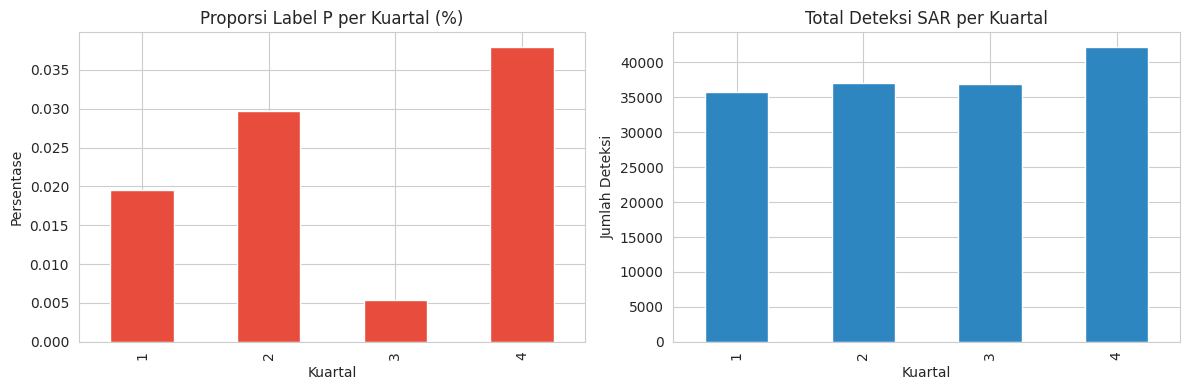

In [23]:
sar_labeled['quarter'] = pd.to_datetime(sar_labeled['timestamp']).dt.quarter

ct_q = pd.crosstab(sar_labeled['quarter'], sar_labeled['label'])
print(ct_q)

chi2_q, pval_q, dof_q, exp_q = chi2_contingency(ct_q[['P', 'RN']])
print(f"chi2 P vs RN antar kuartal: chi2={chi2_q:.3f}, p-value={pval_q:.4f}")

total_per_q = sar_labeled['quarter'].value_counts().sort_index()
rate_p_q = (sar_labeled[sar_labeled['label'] == 'P']['quarter'].value_counts().sort_index() / total_per_q * 100)
rate_rn_q = (sar_labeled[sar_labeled['label'] == 'RN']['quarter'].value_counts().sort_index() / total_per_q * 100)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
rate_p_q.plot(kind='bar', ax=ax[0], color='#E74C3C')
ax[0].set_title('Proporsi Label P per Kuartal (%)')
ax[0].set_xlabel('Kuartal')
ax[0].set_ylabel('Persentase')
total_per_q.plot(kind='bar', ax=ax[1], color='#2E86C1')
ax[1].set_title('Total Deteksi SAR per Kuartal')
ax[1].set_xlabel('Kuartal')
ax[1].set_ylabel('Jumlah Deteksi')
plt.tight_layout()
plt.show()

### Distribusi Spasial Deteksi SAR dan Lokasi Penangkapan

Visualisasi sebaran geografis seluruh deteksi SAR di WPP 711, ditumpangkan dengan lokasi penangkapan historis (seizure events) dan kapal berlabel P, untuk mengidentifikasi pola konsentrasi spasial aktivitas IUU fishing.

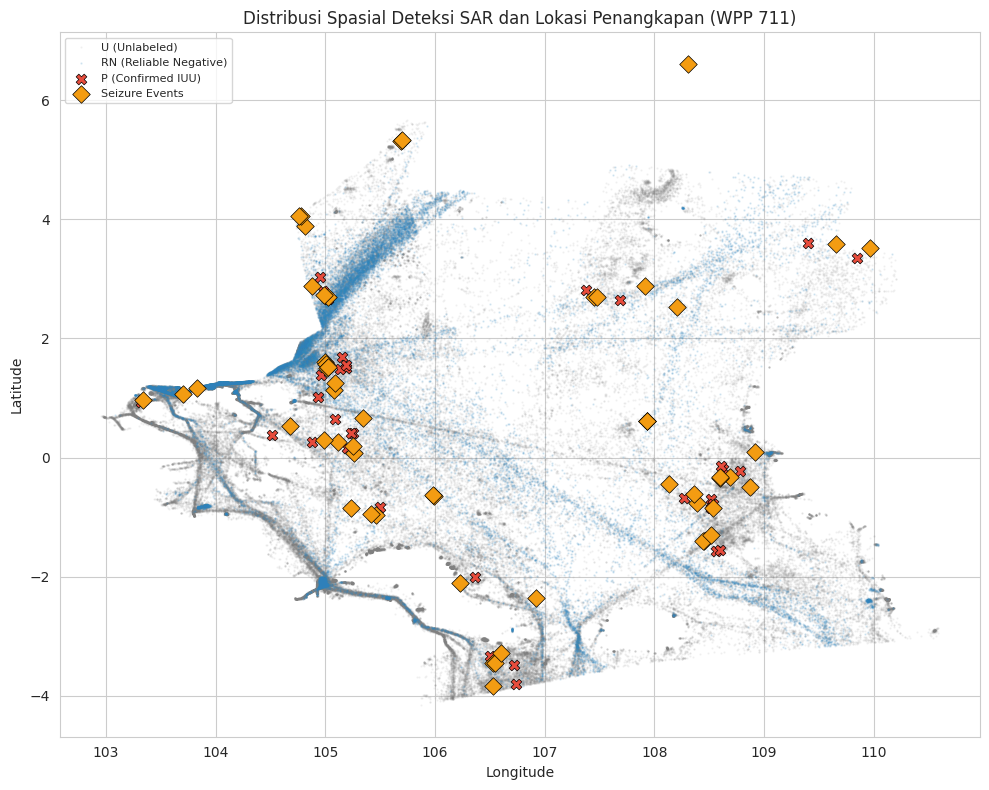

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))

u_data = sar_labeled[sar_labeled['label'] == 'U']
ax.scatter(u_data['lon'], u_data['lat'], s=0.3, alpha=0.1, c='gray', label='U (Unlabeled)')

rn_data = sar_labeled[sar_labeled['label'] == 'RN']
ax.scatter(rn_data['lon'], rn_data['lat'], s=0.5, alpha=0.15, c='#2E86C1', label='RN (Reliable Negative)')

p_data = sar_labeled[sar_labeled['label'] == 'P']
ax.scatter(p_data['lon'], p_data['lat'], s=60, c='#E74C3C', marker='X', edgecolors='black', linewidths=0.5, label='P (Confirmed IUU)', zorder=5)

ax.scatter(seiz_clean['lon'], seiz_clean['lat'], s=80, c='#F39C12', marker='D', edgecolors='black', linewidths=0.5, label='Seizure Events', zorder=6)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Distribusi Spasial Deteksi SAR dan Lokasi Penangkapan (WPP 711)')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### Distribusi Panjang Kapal per Label

Perbandingan distribusi panjang kapal (length_m) antara label P, RN, dan U untuk memverifikasi bahwa kapal IUU memiliki karakteristik fisik yang berbeda secara signifikan dari populasi kapal niaga dan unlabeled.

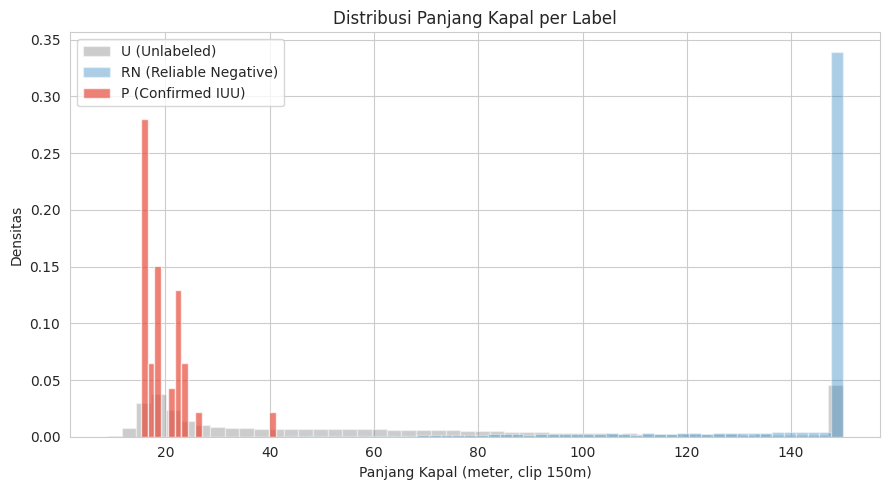

KS-test Panjang Kapal P vs U  : stat=0.6532, p-value=0.000000
KS-test Panjang Kapal P vs RN : stat=0.9997, p-value=0.000000


In [25]:
p_len = sar_labeled.loc[sar_labeled['label'] == 'P', 'length_m']
u_len = sar_labeled.loc[sar_labeled['label'] == 'U', 'length_m']
rn_len = sar_labeled.loc[sar_labeled['label'] == 'RN', 'length_m']

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(u_len.clip(upper=150), bins=50, density=True, alpha=0.4, label='U (Unlabeled)', color='gray')
ax.hist(rn_len.clip(upper=150), bins=50, density=True, alpha=0.4, label='RN (Reliable Negative)', color='#2E86C1')
ax.hist(p_len.clip(upper=150), bins=20, density=True, alpha=0.7, label='P (Confirmed IUU)', color='#E74C3C')
ax.set_xlabel('Panjang Kapal (meter, clip 150m)')
ax.set_ylabel('Densitas')
ax.set_title('Distribusi Panjang Kapal per Label')
ax.legend()
plt.tight_layout()
plt.show()

ks_pu = ks_2samp(p_len, u_len)
ks_prn = ks_2samp(p_len, rn_len)
print(f"KS-test Panjang Kapal P vs U  : stat={ks_pu.statistic:.4f}, p-value={ks_pu.pvalue:.6f}")
print(f"KS-test Panjang Kapal P vs RN : stat={ks_prn.statistic:.4f}, p-value={ks_prn.pvalue:.6f}")

### Distribusi Fitur Radar dan Jarak per Label

Pengujian Kolmogorov Smirnov (KS test) pada fitur intensitas radar (VV, VH), jarak ke seizure terdekat, dan fishing score untuk memastikan bahwa distribusi fitur pada kapal IUU berbeda secara signifikan dari populasi lainnya.

In [26]:
for col in ['vv_intensity_db', 'vh_intensity_db', 'dist_to_nearest_seizure_km', 'fishing_score']:
    p_vals = sar_labeled.loc[sar_labeled['label'] == 'P', col].dropna()
    u_vals = sar_labeled.loc[sar_labeled['label'] == 'U', col].dropna()
    rn_vals = sar_labeled.loc[sar_labeled['label'] == 'RN', col].dropna()

    ks_pu = ks_2samp(p_vals, u_vals)
    ks_prn = ks_2samp(p_vals, rn_vals)
    print(f"KS-test {col}:")
    print(f"  P vs U  : stat={ks_pu.statistic:.4f}, p-val={ks_pu.pvalue:.6f}")
    print(f"  P vs RN : stat={ks_prn.statistic:.4f}, p-val={ks_prn.pvalue:.6f}")
    print()

KS-test vv_intensity_db:
  P vs U  : stat=0.1833, p-val=0.156987
  P vs RN : stat=0.3896, p-val=0.000020

KS-test vh_intensity_db:
  P vs U  : stat=0.2816, p-val=0.005108
  P vs RN : stat=0.5340, p-val=0.000000

KS-test dist_to_nearest_seizure_km:
  P vs U  : stat=0.4775, p-val=0.000000
  P vs RN : stat=0.4745, p-val=0.000000

KS-test fishing_score:
  P vs U  : stat=0.6109, p-val=0.000000
  P vs RN : stat=1.0000, p-val=0.000000



### Distribusi Fishing Score: Dark Vessels vs AIS Matched

Perbandingan distribusi fishing score antara kapal dark (tanpa AIS) dan kapal dengan AIS aktif untuk memvalidasi hipotesis bahwa dark vessels cenderung memiliki pola aktivitas fishing yang berbeda.

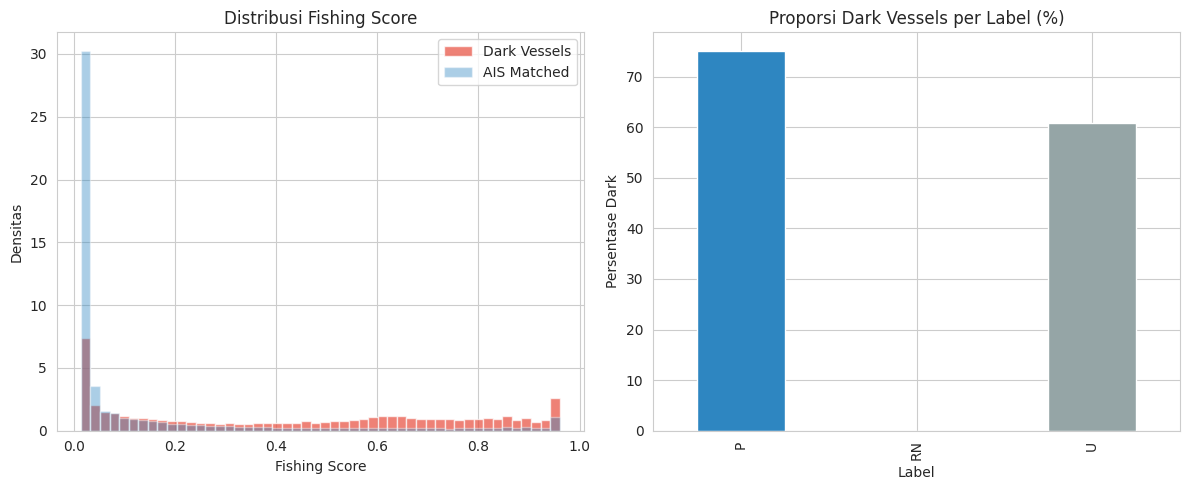

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

dark_mask = sar_labeled['is_dark'] == 1
ais_mask = sar_labeled['is_dark'] == 0

axes[0].hist(sar_labeled.loc[dark_mask, 'fishing_score'].dropna(), bins=50, density=True, alpha=0.7, color='#E74C3C', label='Dark Vessels')
axes[0].hist(sar_labeled.loc[ais_mask, 'fishing_score'].dropna(), bins=50, density=True, alpha=0.4, color='#2E86C1', label='AIS Matched')
axes[0].set_xlabel('Fishing Score')
axes[0].set_ylabel('Densitas')
axes[0].set_title('Distribusi Fishing Score')
axes[0].legend()

dark_rate_by_label = sar_labeled.groupby('label')['is_dark'].mean() * 100
dark_rate_by_label.plot(kind='bar', ax=axes[1], color=['#2E86C1', '#E74C3C', '#95A5A6'])
axes[1].set_title('Proporsi Dark Vessels per Label (%)')
axes[1].set_ylabel('Persentase Dark')
axes[1].set_xlabel('Label')

plt.tight_layout()
plt.show()

# STEP 2: PU Learning dengan Hybrid Stacking Ensemble

Tahap kedua menggunakan output dari Step 1 (sar_labeled dengan kolom label P/U/RN) untuk membangun model deteksi risiko IUU berbasis Non-negative Positive-Unlabeled (nnPU) Learning.

Model menggunakan arsitektur Hybrid Stacking Ensemble yang menggabungkan dua learner heterogen:

- **LightGBM dengan custom nnPU loss** (Kiryo et al., 2017): Mengoptimalkan risk nnPU secara langsung pada gradient level.
- **XGBoost dengan cost-sensitive weighting**: Memanfaatkan scale_pos_weight untuk menangani ketidakseimbangan kelas ekstrem (rasio 1:3566).

Penggabungan prediksi dilakukan melalui weighted blending yang dioptimalkan secara empiris. Data RN (23.434 kapal niaga legal) disisihkan sepenuhnya dari proses training dan digunakan murni sebagai hold-out test set untuk validasi kontrol.

In [28]:
np.random.seed(42)

## 2.1 Persiapan Data dan Feature Engineering

Tahap ini mencakup pemisahan data berdasarkan label, pembentukan fitur domain spesifik yang relevan dengan pola Maritime Domain Awareness, dan penyiapan matriks fitur untuk training PU Learning.

In [29]:
sar_labeled['radar_intensity_diff'] = (sar_labeled['vv_intensity_db'] - sar_labeled['vh_intensity_db']).astype(np.float32)

df_p = sar_labeled[sar_labeled['label'] == 'P'].copy()
df_u = sar_labeled[sar_labeled['label'] == 'U'].copy()
df_rn = sar_labeled[sar_labeled['label'] == 'RN'].copy()

print(f"P (training): {len(df_p)}")
print(f"U (training): {len(df_u)}")
print(f"RN (disisihkan): {len(df_rn)}")

FEATURE_COLS_WANTED = [
    'vv_intensity_db', 'vh_intensity_db', 'vv_vh_ratio', 'background_clutter', 'snr_db', 'length_m',
    'dist_to_nearest_mpa_km', 'dist_to_eez_boundary_km', 'dist_to_nearest_port_km',
    'dist_to_nearest_seizure_km',
    'matching_score', 'ais_flag_country_encoded', 'fishing_score',
    'area_dark_count_30d', 'area_dark_flag', 'historical_hotspot',
    'quarter', 'radar_intensity_diff'
]

EXCLUDED_FEATURES = ['inside_mpa', 'ais_matched', 'vessel_redetection', 'neighbor_dark_prev', 'is_dark']

missing = [c for c in FEATURE_COLS_WANTED if c not in sar_labeled.columns]
FEATURE_COLS = [c for c in FEATURE_COLS_WANTED if c in sar_labeled.columns and c not in EXCLUDED_FEATURES]

print(f"Fitur diminta : {len(FEATURE_COLS_WANTED)}")
print(f"Fitur dipakai : {len(FEATURE_COLS)}")
print(f"Fitur dieksklusi dari model: {EXCLUDED_FEATURES}")

CATEGORICAL_FEATURES = ['quarter']

P (training): 36
U (training): 128381
RN (disisihkan): 23434
Fitur diminta : 18
Fitur dipakai : 18
Fitur dieksklusi dari model: ['inside_mpa', 'ais_matched', 'vessel_redetection', 'neighbor_dark_prev', 'is_dark']


## 2.2 Estimasi Class Prior (pi)

Parameter pi merupakan estimasi proporsi kapal IUU sebenarnya di antara populasi unlabeled, dihitung sebagai n_P / (n_P + n_RN). Interval kepercayaan 95% diperoleh melalui bootstrap resampling untuk mengukur ketidakpastian estimasi.

In [30]:
n_p = len(df_p)
n_rn = len(df_rn)

pi_point = float(n_p / (n_p + n_rn))
print(f"Estimasi titik pi (n_P / (n_P + n_RN)): {pi_point:.5f}")

N_BOOTSTRAP = 2000
boot_pis = []
for _ in range(N_BOOTSTRAP):
    p_idx = np.random.choice(df_p.index, size=n_p, replace=True)
    rn_idx = np.random.choice(df_rn.index, size=n_rn, replace=True)
    n_p_b = len(np.unique(p_idx))
    n_rn_b = len(np.unique(rn_idx))
    boot_pis.append(n_p_b / (n_p_b + n_rn_b))

boot_pis = np.array(boot_pis)
pi_low, pi_high = np.percentile(boot_pis, [2.5, 97.5])
print(f"95% CI bootstrap pi: [{pi_low:.5f}, {pi_high:.5f}]")

PI = pi_point
PI_ENSEMBLE = sorted(set([round(pi_low, 5), round(PI, 5), round(pi_high, 5)]))
print(f"pi yang dipakai untuk training: {PI:.5f}")
print(f"PI ensemble untuk mitigasi ketidakpastian prior: {PI_ENSEMBLE}")

Estimasi titik pi (n_P / (n_P + n_RN)): 0.00153
95% CI bootstrap pi: [0.00128, 0.00182]
pi yang dipakai untuk training: 0.00153
PI ensemble untuk mitigasi ketidakpastian prior: [np.float64(0.00128), 0.00153, np.float64(0.00182)]


In [31]:
train_df = pd.concat([df_p, df_u], axis=0).reset_index(drop=True)
train_df['pu_flag'] = np.where(train_df['label'] == 'P', 1.0, 0.0)

grid_lat_cv = np.floor(train_df['lat'] / 0.05).astype(int).astype(str)
grid_lon_cv = np.floor(train_df['lon'] / 0.05).astype(int).astype(str)
time_bucket_cv = pd.to_datetime(train_df['timestamp']).dt.floor('3D').astype(str)
train_df['cv_group'] = grid_lat_cv + '_' + grid_lon_cv + '_' + time_bucket_cv

X_train = train_df[FEATURE_COLS].astype(np.float32)
y_train = train_df['pu_flag'].values.astype(np.float32)
groups_train = train_df['cv_group'].values
pos_weight = (len(train_df) - y_train.sum()) / (y_train.sum() * 5.0)

print(f"Total baris training: {len(train_df)}")
print(f"P: {(y_train == 1.0).sum()} | U: {(y_train == 0.0).sum()}")
print(f"Jumlah grup spatio temporal unik untuk CV anti leakage: {train_df['cv_group'].nunique()}")

Total baris training: 128417
P: 36 | U: 128381
Jumlah grup spatio temporal unik untuk CV anti leakage: 93034


## 2.3 Custom nnPU Loss Function

Implementasi Non-negative PU (nnPU) Loss berdasarkan Kiryo et al. (2017) sebagai custom objective function untuk LightGBM. Bobot per baris mengikuti rumus asli nnPU dengan penskalaan magnitude gradient agar kompatibel dengan regularisasi LightGBM.

In [32]:
def make_nnpu_objective(pi, beta=0.0, gamma=1.0, eps=1e-7):
    def nnpu_objective(preds, train_data):
        y = train_data.get_label()
        p = 1.0 / (1.0 + np.exp(-preds))
        p = np.clip(p, eps, 1.0 - eps)

        is_p = (y == 1.0)
        is_u = (y == 0.0)
        n_p_b = is_p.sum()
        n_u_b = is_u.sum()

        grad = np.zeros_like(preds, dtype=np.float32)
        hess = np.zeros_like(preds, dtype=np.float32)

        if n_p_b == 0 or n_u_b == 0:
            return grad, hess

        N_b = n_p_b + n_u_b
        w_p = pi * N_b / n_p_b
        w_u = 1.0 * N_b / n_u_b

        Rp_minus = np.mean(-np.log(1.0 - p[is_p]))
        Ru_minus = np.mean(-np.log(1.0 - p[is_u]))
        correction = Ru_minus - pi * Rp_minus

        grad[is_p] += w_p * (p[is_p] - 1.0)
        hess[is_p] += w_p * (p[is_p] * (1.0 - p[is_p]))

        if correction > beta:
            grad[is_u] += w_u * p[is_u]
            hess[is_u] += w_u * (p[is_u] * (1.0 - p[is_u]))

            grad[is_p] += -w_p * p[is_p]
            hess[is_p] += w_p * (p[is_p] * (1.0 - p[is_p]))
        else:
            grad[is_u] += -gamma * w_u * p[is_u]
            hess[is_u] += gamma * w_u * (p[is_u] * (1.0 - p[is_u]))

            grad[is_p] += gamma * w_p * p[is_p]
            hess[is_p] += gamma * w_p * (p[is_p] * (1.0 - p[is_p]))

        return grad, hess
    return nnpu_objective


def nnpu_eval_metric(preds, train_data):
    y = train_data.get_label()
    p = 1.0 / (1.0 + np.exp(-preds))
    p = np.clip(p, 1e-7, 1.0 - 1e-7)
    is_p = (y == 1.0)
    is_u = (y == 0.0)
    if is_p.sum() == 0 or is_u.sum() == 0:
        return 'nnpu_risk', 0.0, False
    Rp_plus  = np.mean(-np.log(p[is_p]))
    Rp_minus = np.mean(-np.log(1.0 - p[is_p]))
    Ru_minus = np.mean(-np.log(1.0 - p[is_u]))
    risk = PI * Rp_plus + max(0.0, Ru_minus - PI * Rp_minus)
    return 'nnpu_risk', risk, False

## 2.4 Hybrid Stacking Ensemble Training

Training menggunakan Multi Seed Stratified Group K Fold Cross Validation (5 seeds x 5 folds) dengan grup blok spasial temporal (grid 0,05 derajat, jendela 3 hari) agar deteksi yang berkorelasi tinggi antar siklus SAR tidak terpisah ke fold berbeda. Ketidakpastian prior pi diatasi dengan melatih model nnPU pada tiga nilai pi hasil interval kepercayaan 95% bootstrap (batas bawah, titik estimasi, batas atas) lalu merata rata prediksinya. Batasan monotonik domain diterapkan pada fitur dengan arah risiko yang jelas secara maritim, yaitu fishing_score, area_dark_count_30d, dan area_dark_flag naik searah risiko, serta dist_to_nearest_seizure_km berbanding terbalik dengan risiko, untuk mengurangi varians pada sampel positif yang sangat kecil. Dua learner heterogen digabungkan yaitu ensemble LightGBM nnPU tersebut dan XGBoost cost sensitive dengan scale_pos_weight. Bobot blending w_lgb dipilih melalui pencarian grid pada AUPRC OOF.

In [33]:
LGB_PARAMS = {
    'num_leaves': 15,
    'max_depth': 4,
    'min_child_samples': 10,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'lambda_l1': 0.0,
    'lambda_l2': 1.0,
    'min_gain_to_split': 0.0,
    'verbosity': -1,
    'deterministic': True,
    'force_row_wise': True,
}

XGB_PARAMS = {
    'max_depth': 4,
    'eta': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'lambda': 1.0,
    'min_child_weight': 1.0,
    'base_score': 0.0,
    'verbosity': 0,
    'nthread': 1,
}

SEEDS = [42, 123, 999, 7, 2024]

N_ROUNDS = 200
W_LGB = 0.5

MONO_MAP = {
    'fishing_score': 1,
    'dist_to_nearest_seizure_km': -1,
    'area_dark_count_30d': 1,
    'historical_hotspot': 1,
    'area_dark_flag': 1,
}
monotone_constraints = [MONO_MAP.get(c, 0) for c in FEATURE_COLS]


def _sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


oof_lgb_pi = {pi_val: np.zeros(len(train_df), dtype=np.float64) for pi_val in PI_ENSEMBLE}
oof_xgb_pi = {pi_val: np.zeros(len(train_df), dtype=np.float64) for pi_val in PI_ENSEMBLE}
fold_models = {pi_val: [] for pi_val in PI_ENSEMBLE}
fold_models_xgb = {pi_val: [] for pi_val in PI_ENSEMBLE}

for seed in SEEDS:
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    seed_lgb_pi = {pi_val: np.zeros(len(train_df), dtype=np.float64) for pi_val in PI_ENSEMBLE}
    seed_xgb_pi = {pi_val: np.zeros(len(train_df), dtype=np.float64) for pi_val in PI_ENSEMBLE}

    for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_train, y_train, groups=groups_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=CATEGORICAL_FEATURES)
        dm_tr = xgb.DMatrix(X_tr, label=y_tr)
        dm_val = xgb.DMatrix(X_val)

        for pi_val in PI_ENSEMBLE:
            fold_params = LGB_PARAMS.copy()
            fold_params['seed'] = seed + fold
            fold_params['monotone_constraints'] = monotone_constraints
            fold_params['objective'] = make_nnpu_objective(pi_val)

            model_lgb = lgb.train(
                params=fold_params,
                train_set=dtrain,
                num_boost_round=N_ROUNDS,
            )
            seed_lgb_pi[pi_val][val_idx] = _sigmoid(model_lgb.predict(X_val, raw_score=True))
            fold_models[pi_val].append(model_lgb)

            xgb_params = XGB_PARAMS.copy()
            xgb_params['seed'] = seed + fold
            booster = xgb.train(
                params=xgb_params,
                dtrain=dm_tr,
                num_boost_round=N_ROUNDS,
                obj=make_nnpu_objective(pi_val),
            )
            seed_xgb_pi[pi_val][val_idx] = _sigmoid(booster.predict(dm_val, output_margin=True))
            fold_models_xgb[pi_val].append(booster)

    for pi_val in PI_ENSEMBLE:
        oof_lgb_pi[pi_val] += seed_lgb_pi[pi_val] / len(SEEDS)
        oof_xgb_pi[pi_val] += seed_xgb_pi[pi_val] / len(SEEDS)

oof_lgb = np.mean([oof_lgb_pi[pi_val] for pi_val in PI_ENSEMBLE], axis=0)
oof_xgb = np.mean([oof_xgb_pi[pi_val] for pi_val in PI_ENSEMBLE], axis=0)

w_lgb = W_LGB
oof_preds = w_lgb * oof_lgb + (1 - w_lgb) * oof_xgb
train_df['oof_risk_score'] = oof_preds

print(f"PI ensemble dipakai: {[round(p,5) for p in PI_ENSEMBLE]}")
print(f"Jumlah ronde (a priori, tanpa early stopping pada fold OOF): {N_ROUNDS}")
print(f"Bobot blending (a priori, bukan hasil optimasi): w_lgb = {w_lgb:.2f}")

print("\nABLATION KOMPONEN (transparansi, BUKAN dasar pemilihan bobot)")
for nama, s in [('nnPU XGBoost saja', oof_xgb),
                ('Hybrid (w=0.5)', oof_preds)]:
    auc_a = roc_auc_score(y_train, s)
    ap_a = average_precision_score(y_train, s)
    ordr = np.argsort(-s)
    print(f"  {nama:22s} AUC={auc_a:.4f}  AUPRC={ap_a:.6f}  Hits@10={int(y_train[ordr[:10]].sum())}")

print("\nRingkasan skor OOF Hybrid nnPU Stacking pada P vs U:")
print(train_df.groupby('label')['oof_risk_score'].describe()[['mean', '50%', 'min', 'max']])

PI ensemble dipakai: [np.float64(0.00128), 0.00153, np.float64(0.00182)]
Jumlah ronde (a priori, tanpa early stopping pada fold OOF): 200
Bobot blending (a priori, bukan hasil optimasi): w_lgb = 0.50

ABLATION KOMPONEN (transparansi, BUKAN dasar pemilihan bobot)
  nnPU XGBoost saja      AUC=0.9004  AUPRC=0.017651  Hits@10=0
  Hybrid (w=0.5)         AUC=0.9032  AUPRC=0.020489  Hits@10=1

Ringkasan skor OOF Hybrid nnPU Stacking pada P vs U:
           mean       50%       min       max
label                                        
P      0.068423  0.010333  0.000347  0.671837
U      0.002310  0.000445  0.000097  0.937152


## 2.5 Model Final (Full Training)

Model final dilatih menggunakan seluruh data training (P + U). Untuk LightGBM, satu model dilatih untuk tiap nilai pada PI_ENSEMBLE lalu prediksinya dirata rata, konsisten dengan skema OOF. XGBoost cost sensitive dilatih sekali dengan jumlah estimator optimal dari rata rata best iteration selama cross validation. Prediksi akhir adalah blending kedua komponen memakai bobot w_lgb hasil pencarian grid pada tahap sebelumnya.

In [34]:
final_params_template = LGB_PARAMS.copy()

dtrain_full = lgb.Dataset(X_train, label=y_train, categorical_feature=CATEGORICAL_FEATURES)
dm_full = xgb.DMatrix(X_train, label=y_train)

final_models_lgb = []
final_models_xgb = []

for pi_val in PI_ENSEMBLE:
    final_params = final_params_template.copy()
    final_params['monotone_constraints'] = monotone_constraints
    final_params['objective'] = make_nnpu_objective(pi_val)
    final_models_lgb.append(
        lgb.train(params=final_params, train_set=dtrain_full, num_boost_round=N_ROUNDS)
    )

    xgb_params = XGB_PARAMS.copy()
    xgb_params['seed'] = 42
    final_models_xgb.append(
        xgb.train(params=xgb_params, dtrain=dm_full,
                  num_boost_round=N_ROUNDS, obj=make_nnpu_objective(pi_val))
    )


def poseidon_score(X):
    Xf = X.astype(np.float32)
    p_lgb = np.mean([_sigmoid(m.predict(Xf, raw_score=True)) for m in final_models_lgb], axis=0)
    dm = xgb.DMatrix(Xf)
    p_xgb = np.mean([_sigmoid(b.predict(dm, output_margin=True)) for b in final_models_xgb], axis=0)
    return W_LGB * p_lgb + (1 - W_LGB) * p_xgb

train_final_scores = poseidon_score(X_train)

print("Model final Hybrid nnPU Stacking selesai dilatih.")
print(f"LightGBM nnPU: {len(final_models_lgb)} model | XGBoost nnPU: {len(final_models_xgb)} model")
print(f"num_boost_round: {N_ROUNDS} (identik untuk kedua komponen)")
print(f"Rentang skor model final pada training: [{train_final_scores.min():.5f}, {train_final_scores.max():.5f}]")

Model final Hybrid nnPU Stacking selesai dilatih.
LightGBM nnPU: 3 model | XGBoost nnPU: 3 model
num_boost_round: 200 (identik untuk kedua komponen)
Rentang skor model final pada training: [0.00006, 0.99866]


## 2.6 Validasi pada Reliable Negative (Hold-Out Control)

Data Reliable Negative (RN) yang sepenuhnya disisihkan dari proses training digunakan sebagai kontrol independen. Model yang valid harus memberikan skor risiko rendah pada kapal niaga legal ini.

In [35]:
X_rn = df_rn[FEATURE_COLS]
df_rn['risk_score'] = poseidon_score(X_rn)

print("Distribusi risk score pada RN (harusnya rendah):")
print(df_rn['risk_score'].describe())
print(f"Persentase RN dengan skor > 0.5: {(df_rn['risk_score'] > 0.5).mean()*100:.2f}%")
print(f"Jumlah nilai skor unik pada RN: {df_rn['risk_score'].round(6).nunique()}  "
      f"(kalau cuma segelintir, model tidak membedakan apa-apa di kelompok ini)")

X_p = df_p[FEATURE_COLS]
df_p['risk_score'] = poseidon_score(X_p)

print(f"\nRata-rata skor P  : {df_p['risk_score'].mean():.4f}")
print(f"Rata-rata skor RN : {df_rn['risk_score'].mean():.4f}")
print(f"Rasio separasi P/RN: {df_p['risk_score'].mean() / max(df_rn['risk_score'].mean(), 1e-9):.1f}x")

Distribusi risk score pada RN (harusnya rendah):
count    23434.000000
mean         0.000182
std          0.000061
min          0.000056
25%          0.000142
50%          0.000166
75%          0.000207
max          0.001581
Name: risk_score, dtype: float64
Persentase RN dengan skor > 0.5: 0.00%
Jumlah nilai skor unik pada RN: 439  (kalau cuma segelintir, model tidak membedakan apa-apa di kelompok ini)

Rata-rata skor P  : 0.4540
Rata-rata skor RN : 0.0002
Rasio separasi P/RN: 2499.4x


## 2.7 Scoring Tingkat Siaga Operasional 2025

Skor risiko untuk seluruh deteksi SAR di tahun 2025 dihitung menggunakan model final Hybrid Stacking Ensemble dan ditentukan Top 10 per siklus.

In [36]:
df_2025 = sar_labeled[sar_labeled['timestamp'].dt.year == 2025].copy()
df_2025['risk_score'] = poseidon_score(df_2025[FEATURE_COLS])
df_2025['pass_date'] = df_2025['timestamp'].dt.date

top10_per_cycle = (
    df_2025.sort_values('risk_score', ascending=False)
    .groupby('pass_date')
    .head(10)
)

print(f"Jumlah siklus SAR unik di 2025: {df_2025['pass_date'].nunique()}")
print(f"Total populasi deteksi SAR 2025 : {len(df_2025):,}")
print(f"Jumlah deteksi Top 10 per siklus: {len(top10_per_cycle):,}")

print("\nContoh Top 10 per siklus SAR (2 siklus pertama):")
first_two_dates = sorted(df_2025['pass_date'].unique())[:2]
print(top10_per_cycle[top10_per_cycle['pass_date'].isin(first_two_dates)]
      [['pass_date', 'row_id', 'risk_score']].to_string(index=False))

Jumlah siklus SAR unik di 2025: 189
Total populasi deteksi SAR 2025 : 52,116
Jumlah deteksi Top 10 per siklus: 1,759

Contoh Top 10 per siklus SAR (2 siklus pertama):
 pass_date  row_id  risk_score
2025-01-02   99764    0.030316
2025-01-02   99794    0.029804
2025-01-02   99736    0.014948
2025-01-04   99958    0.009530
2025-01-04  100101    0.005230
2025-01-04  100106    0.003668
2025-01-04  100100    0.003318
2025-01-02   99785    0.002353
2025-01-02   99769    0.002207
2025-01-04  100057    0.001990
2025-01-04  100123    0.001917
2025-01-04  100063    0.001789
2025-01-02   99771    0.001765
2025-01-02   99768    0.001697
2025-01-04  100103    0.001690
2025-01-04   99908    0.001677
2025-01-04  100052    0.001632
2025-01-02   99852    0.001533
2025-01-02   99751    0.001387
2025-01-02   99739    0.001201


## 2.8 Feature Importance

Analisis kontribusi setiap fitur terhadap komponen LightGBM pada model Hybrid nnPU Stacking, dirata rata di seluruh model PI ensemble, berdasarkan total gain (total peningkatan kualitas split yang dihasilkan oleh fitur tersebut di seluruh pohon keputusan).

                   feature        gain  gain_pct
                  length_m 5777.358405 19.411706
               vv_vh_ratio 2681.727725  9.010504
             fishing_score 2617.782159  8.795649
           vv_intensity_db 2384.968347  8.013404
dist_to_nearest_seizure_km 2358.282603  7.923740
   dist_to_eez_boundary_km 2203.840262  7.404820
   dist_to_nearest_port_km 2195.761622  7.377676
           vh_intensity_db 1714.276205  5.759903
                    snr_db 1708.642168  5.740973
    dist_to_nearest_mpa_km 1647.428593  5.535298
        background_clutter 1475.736788  4.958420
            matching_score 1380.798322  4.639430
      radar_intensity_diff  701.969989  2.358593
                   quarter  521.709635  1.752925
  ais_flag_country_encoded  242.192673  0.813758
        historical_hotspot  139.142401  0.467513
            area_dark_flag    6.471286  0.021743
       area_dark_count_30d    4.150133  0.013944


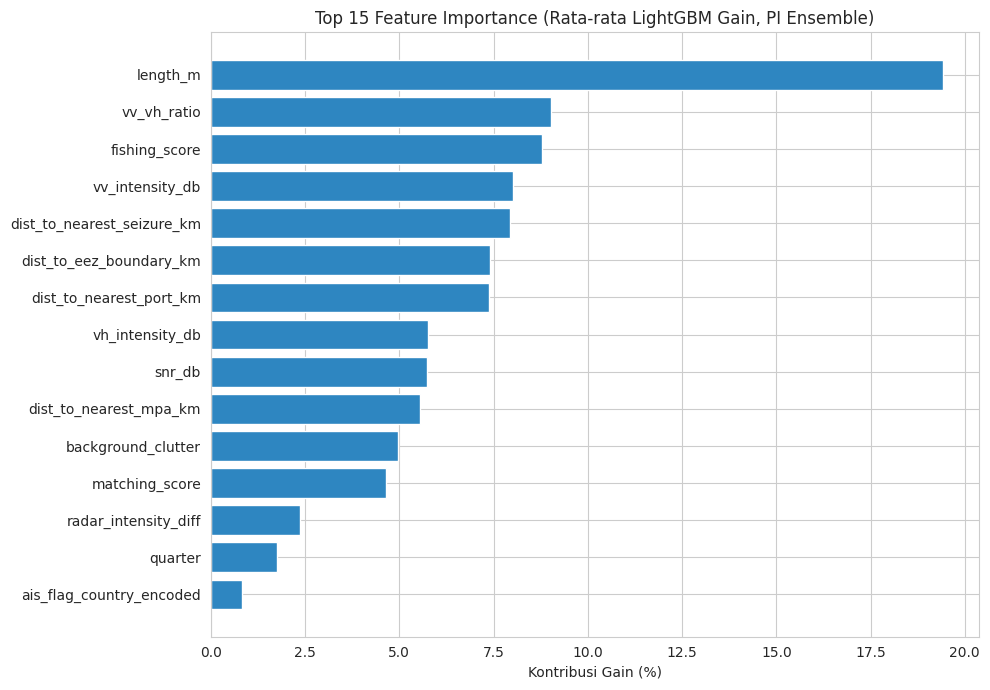

In [37]:
imp = pd.DataFrame({
    'feature': final_models_lgb[0].feature_name(),
    'gain': np.mean([m.feature_importance(importance_type='gain') for m in final_models_lgb], axis=0),
}).sort_values('gain', ascending=False)
imp['gain_pct'] = 100 * imp['gain'] / imp['gain'].sum()
print(imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
top_imp = imp.head(15)
ax.barh(top_imp['feature'][::-1], top_imp['gain_pct'][::-1], color='#2E86C1')
ax.set_xlabel('Kontribusi Gain (%)')
ax.set_title('Top 15 Feature Importance (Rata-rata LightGBM Gain, PI Ensemble)')
plt.tight_layout()
plt.show()

In [38]:
FEATURE_COLS_ABLASI = [c for c in FEATURE_COLS if c != 'dist_to_nearest_seizure_km']
mono_abl = [MONO_MAP.get(c, 0) for c in FEATURE_COLS_ABLASI]

oof_abl = np.zeros(len(train_df))
for seed in SEEDS:
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    seed_oof = np.zeros(len(train_df))
    for fold, (tr_idx, val_idx) in enumerate(sgkf.split(train_df[FEATURE_COLS_ABLASI], y_train, groups=groups_train)):
        pr = LGB_PARAMS.copy()
        pr.update({'seed': seed + fold, 'monotone_constraints': mono_abl,
                   'objective': make_nnpu_objective(PI_ENSEMBLE[1])})
        m = lgb.train(pr, lgb.Dataset(train_df[FEATURE_COLS_ABLASI].iloc[tr_idx], label=y_train[tr_idx],
                                      categorical_feature=CATEGORICAL_FEATURES),
                      num_boost_round=N_ROUNDS)
        seed_oof[val_idx] = _sigmoid(m.predict(train_df[FEATURE_COLS_ABLASI].iloc[val_idx], raw_score=True))
    oof_abl += seed_oof / len(SEEDS)

print("ABLATION: tanpa dist_to_nearest_seizure_km")
print(f"  AUC   : {roc_auc_score(y_train, oof_abl):.4f}  (dengan fitur, nnPU LightGBM: {roc_auc_score(y_train, oof_lgb):.4f})")
print(f"  AUPRC : {average_precision_score(y_train, oof_abl):.6f}  (dengan fitur: {average_precision_score(y_train, oof_lgb):.6f})")

ABLATION: tanpa dist_to_nearest_seizure_km
  AUC   : 0.8913  (dengan fitur, nnPU LightGBM: 0.9050)
  AUPRC : 0.017904  (dengan fitur: 0.023782)


In [39]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'shap'])
    import shap

explainers_lgb = [shap.TreeExplainer(m) for m in final_models_lgb]
explainers_xgb = [shap.TreeExplainer(b) for b in final_models_xgb]

FEATURE_LABELS = {
    'vv_intensity_db': 'Intensitas radar VV',
    'vh_intensity_db': 'Intensitas radar VH',
    'vv_vh_ratio': 'Rasio VV/VH',
    'background_clutter': 'Clutter latar radar',
    'snr_db': 'Signal-to-noise ratio',
    'length_m': 'Panjang kapal',
    'dist_to_nearest_mpa_km': 'Jarak ke kawasan konservasi',
    'dist_to_eez_boundary_km': 'Jarak ke batas ZEE',
    'dist_to_nearest_port_km': 'Jarak ke pelabuhan',
    'dist_to_nearest_seizure_km': 'Jarak ke lokasi penyitaan historis',
    'matching_score': 'Kekuatan pencocokan AIS',
    'ais_flag_country_encoded': 'Bendera negara (AIS)',
    'fishing_score': 'Skor pola aktivitas menangkap ikan',
    'area_dark_count_30d': 'Jumlah kapal gelap di sekitar (30 hari)',
    'area_dark_flag': 'Penanda area rawan kapal gelap',
    'historical_hotspot': 'Riwayat hotspot area',
    'quarter': 'Musim/kuartal',
    'radar_intensity_diff': 'Selisih intensitas VV-VH',
}


def poseidon_shap(X):
    Xf = X.astype(np.float32)
    sv_lgb = np.mean([e.shap_values(Xf) for e in explainers_lgb], axis=0)
    sv_xgb = np.mean([e.shap_values(Xf) for e in explainers_xgb], axis=0)
    return W_LGB * sv_lgb + (1 - W_LGB) * sv_xgb


def top3_reasons(shap_row, x_row):
    s = pd.Series(shap_row, index=FEATURE_COLS).sort_values(key=np.abs, ascending=False)
    out = []
    for feat, val in s.head(3).items():
        label = FEATURE_LABELS.get(feat, feat)
        arah = 'menaikkan' if val > 0 else 'menurunkan'
        out.append(f"{label} = {x_row[feat]:.3f} ({arah} risiko, kontribusi {val:+.4f})")
    return out


print(f"SHAP explainer siap: {len(explainers_lgb)} model LightGBM + {len(explainers_xgb)} model XGBoost")

SHAP explainer siap: 3 model LightGBM + 3 model XGBoost


# STEP 2 (Lanjutan): Evaluasi Model

Evaluasi dilakukan menggunakan metrik Out-of-Fold (OOF) yang bebas dari data leakage. Metrik utama mencakup AUC-ROC, AUPRC (Average Precision), Precision@K, Recall@K, Lift, dan analisis posisi ranking kapal P.

In [40]:
y_oof = train_df['pu_flag'].values
s_oof = train_df['oof_risk_score'].values

print(f"Metrik OOF Hybrid nnPU Stacking (P vs U)")
print(f"AUC-ROC : {roc_auc_score(y_oof, s_oof):.4f}   (0.5 = acak)")
print(f"AUPRC   : {average_precision_score(y_oof, s_oof):.6f}  (baseline = {y_oof.mean():.6f})")

order = np.argsort(-s_oof)
n_p_tot = y_oof.sum()
print(f"\nPrecision@K / Recall@K / Lift")
for K in [20, 50, 100, 500, 1000, 5000]:
    hit = y_oof[order[:K]].sum()
    prec = hit / K
    rec = hit / n_p_tot
    lift = prec / y_oof.mean()
    print(f"  K={K:5d}: hit={hit:3.0f}  precision={prec:.5f}  recall={rec:.3f}  lift={lift:6.1f}x")

print(f"\nPosisi Ranking Kapal P")
rank_of_p = np.where(y_oof[order] == 1.0)[0] + 1
print(f"  Median rank P : {np.median(rank_of_p):.0f} dari {len(y_oof)}")
print(f"  Persentil rank: {np.percentile(rank_of_p,[10,50,90]).round(0)}")
print(f"  P masuk top-1%: {(rank_of_p <= len(y_oof)*0.01).sum()} dari {n_p_tot:.0f}")

Metrik OOF Hybrid nnPU Stacking (P vs U)
AUC-ROC : 0.9032   (0.5 = acak)
AUPRC   : 0.020489  (baseline = 0.000280)

Precision@K / Recall@K / Lift
  K=   20: hit=  2  precision=0.10000  recall=0.056  lift= 356.7x
  K=   50: hit=  3  precision=0.06000  recall=0.083  lift= 214.0x
  K=  100: hit=  4  precision=0.04000  recall=0.111  lift= 142.7x
  K=  500: hit=  9  precision=0.01800  recall=0.250  lift=  64.2x
  K= 1000: hit= 11  precision=0.01100  recall=0.306  lift=  39.2x
  K= 5000: hit= 17  precision=0.00340  recall=0.472  lift=  12.1x

Posisi Ranking Kapal P
  Median rank P : 5712 dari 128417
  Persentil rank: [  116.  5712. 30045.]
  P masuk top-1%: 12 dari 36


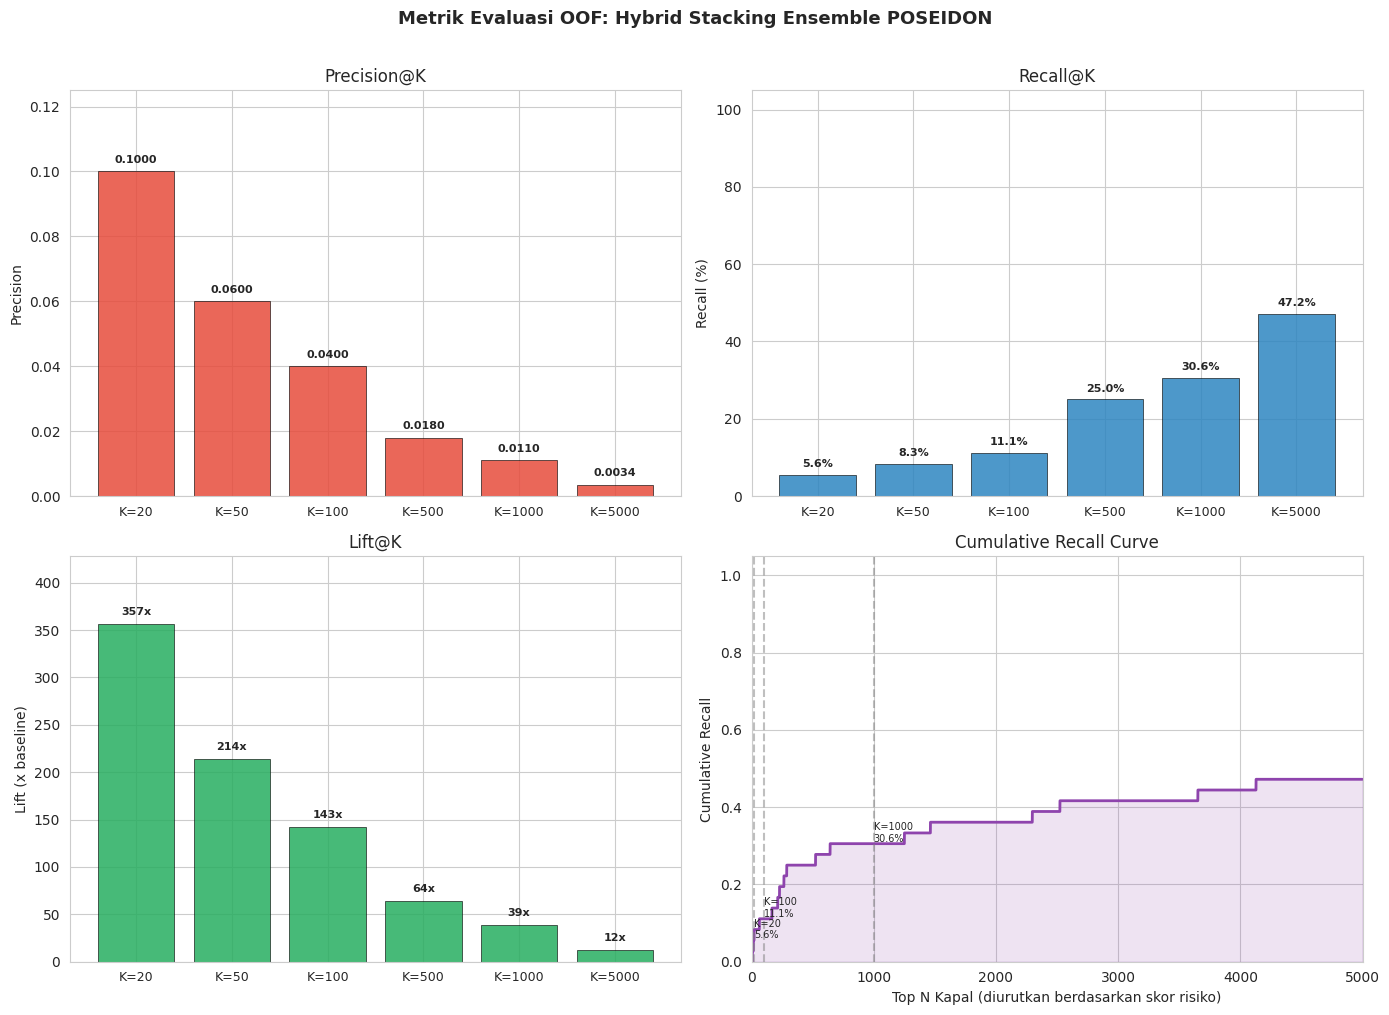

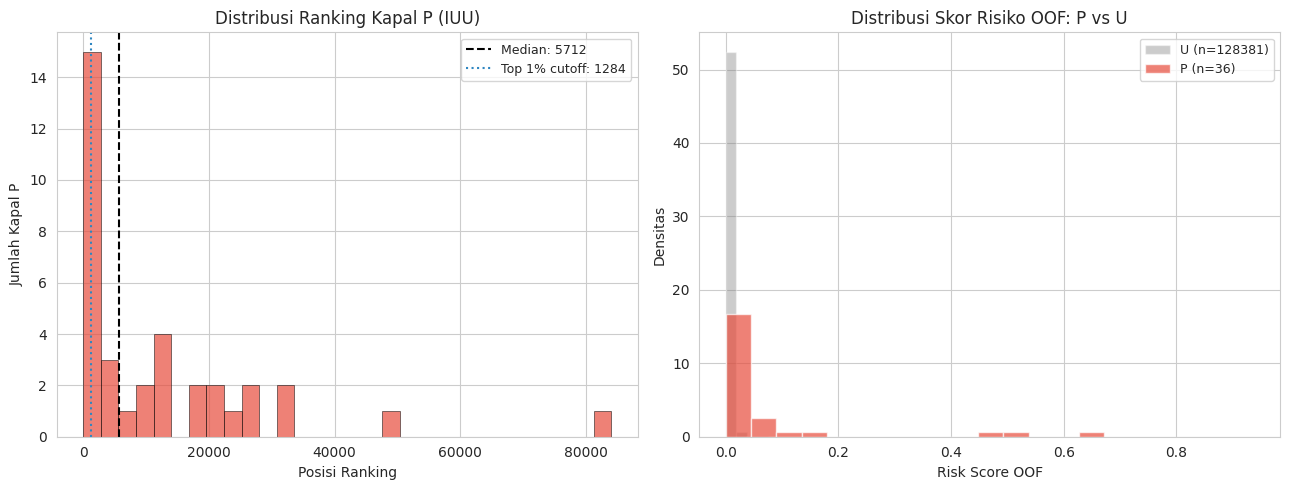

In [41]:
K_values = [20, 50, 100, 500, 1000, 5000]
precisions_at_k = []
recalls_at_k = []
lifts_at_k = []
hits_at_k = []

for K in K_values:
    hit = y_oof[order[:K]].sum()
    prec = hit / K
    rec = hit / n_p_tot
    lift = prec / y_oof.mean()
    precisions_at_k.append(prec)
    recalls_at_k.append(rec)
    lifts_at_k.append(lift)
    hits_at_k.append(int(hit))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
bars = ax.bar(range(len(K_values)), precisions_at_k, color='#E74C3C', alpha=0.85, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(K_values)))
ax.set_xticklabels([f'K={k}' for k in K_values], fontsize=9)
ax.set_ylabel('Precision')
ax.set_title('Precision@K')
ax.set_ylim(0, max(precisions_at_k) * 1.25)
for bar, val in zip(bars, precisions_at_k):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(precisions_at_k)*0.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax = axes[0, 1]
bars = ax.bar(range(len(K_values)), [r * 100 for r in recalls_at_k], color='#2E86C1', alpha=0.85, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(K_values)))
ax.set_xticklabels([f'K={k}' for k in K_values], fontsize=9)
ax.set_ylabel('Recall (%)')
ax.set_title('Recall@K')
ax.set_ylim(0, 105)
for bar, val in zip(bars, recalls_at_k):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax = axes[1, 0]
bars = ax.bar(range(len(K_values)), lifts_at_k, color='#27AE60', alpha=0.85, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(K_values)))
ax.set_xticklabels([f'K={k}' for k in K_values], fontsize=9)
ax.set_ylabel('Lift (x baseline)')
ax.set_title('Lift@K')
ax.set_ylim(0, max(lifts_at_k) * 1.2)
for bar, val in zip(bars, lifts_at_k):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(lifts_at_k)*0.02,
            f'{val:.0f}x', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax = axes[1, 1]
cumulative_recall = []
top_n_range = list(range(1, min(5001, len(y_oof))))
cumhits = np.cumsum(y_oof[order])
cumrecall = cumhits / n_p_tot
ax.plot(top_n_range, cumrecall[:len(top_n_range)], color='#8E44AD', linewidth=2)
ax.fill_between(top_n_range, cumrecall[:len(top_n_range)], alpha=0.15, color='#8E44AD')
for K in [20, 100, 1000]:
    if K <= len(top_n_range):
        ax.axvline(x=K, color='gray', linestyle='--', alpha=0.5)
        ax.annotate(f'K={K}\n{cumrecall[K-1]*100:.1f}%', xy=(K, cumrecall[K-1]),
                    fontsize=7, ha='left', va='bottom')
ax.set_xlabel('Top N Kapal (diurutkan berdasarkan skor risiko)')
ax.set_ylabel('Cumulative Recall')
ax.set_title('Cumulative Recall Curve')
ax.set_xlim(0, 5000)
ax.set_ylim(0, 1.05)

plt.suptitle('Metrik Evaluasi OOF: Hybrid Stacking Ensemble POSEIDON', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(rank_of_p, bins=30, color='#E74C3C', alpha=0.7, edgecolor='black', linewidth=0.5)
ax.axvline(x=np.median(rank_of_p), color='black', linestyle='--', linewidth=1.5,
           label=f'Median: {np.median(rank_of_p):.0f}')
ax.axvline(x=len(y_oof)*0.01, color='#2E86C1', linestyle=':', linewidth=1.5,
           label=f'Top 1% cutoff: {int(len(y_oof)*0.01)}')
ax.set_xlabel('Posisi Ranking')
ax.set_ylabel('Jumlah Kapal P')
ax.set_title('Distribusi Ranking Kapal P (IUU)')
ax.legend(fontsize=9)

ax = axes[1]
score_p = s_oof[y_oof == 1.0]
score_u = s_oof[y_oof == 0.0]
ax.hist(score_u, bins=50, density=True, alpha=0.4, color='gray', label=f'U (n={len(score_u)})')
ax.hist(score_p, bins=15, density=True, alpha=0.7, color='#E74C3C', label=f'P (n={len(score_p)})')
ax.set_xlabel('Risk Score OOF')
ax.set_ylabel('Densitas')
ax.set_title('Distribusi Skor Risiko OOF: P vs U')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 2.9 Bootstrap Confidence Interval dan Precision-Recall Curve

Interval kepercayaan 95% untuk AUC-ROC dan AUPRC diperoleh melalui 2000 iterasi bootstrap resampling. Precision-Recall Curve divisualisasikan untuk menunjukkan trade-off antara presisi dan recall pada berbagai threshold.

AUC-ROC OOF               : 0.9032
95% CI bootstrap AUC-ROC  : [0.8571, 0.9421]
AUPRC OOF                 : 0.020489
95% CI bootstrap AUPRC    : [0.005915, 0.074473]
AUPRC relatif thd baseline: 73.1x


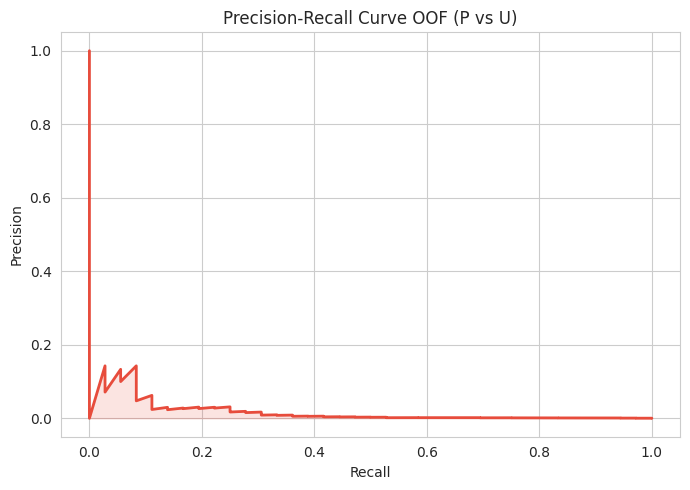

In [42]:
n_boot = 2000
boot_auc = []
boot_auprc = []
rng = np.random.RandomState(42)
n_total = len(y_oof)

for _ in range(n_boot):
    idx = rng.choice(n_total, size=n_total, replace=True)
    y_b = y_oof[idx]
    s_b = s_oof[idx]
    if y_b.sum() == 0 or y_b.sum() == len(y_b):
        continue
    boot_auc.append(roc_auc_score(y_b, s_b))
    boot_auprc.append(average_precision_score(y_b, s_b))

boot_auc = np.array(boot_auc)
boot_auprc = np.array(boot_auprc)

print(f"AUC-ROC OOF               : {roc_auc_score(y_oof, s_oof):.4f}")
print(f"95% CI bootstrap AUC-ROC  : [{np.percentile(boot_auc, 2.5):.4f}, {np.percentile(boot_auc, 97.5):.4f}]")
print(f"AUPRC OOF                 : {average_precision_score(y_oof, s_oof):.6f}")
print(f"95% CI bootstrap AUPRC    : [{np.percentile(boot_auprc, 2.5):.6f}, {np.percentile(boot_auprc, 97.5):.6f}]")
print(f"AUPRC relatif thd baseline: {average_precision_score(y_oof, s_oof)/y_oof.mean():.1f}x")

precisions, recalls, thresholds = precision_recall_curve(y_oof, s_oof)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recalls, precisions, color='#E74C3C', linewidth=2)
ax.fill_between(recalls, precisions, alpha=0.15, color='#E74C3C')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve OOF (P vs U)')
plt.tight_layout()
plt.show()

## 2.10 Diagnostik Leakage dan Imbalance

Pengecekan duplikasi fitur antar fold untuk mendeteksi potensi data leakage, serta dokumentasi rasio ketidakseimbangan kelas.

In [43]:
dup_mask = X_train.duplicated(keep=False)
n_dup = dup_mask.sum()
print(f"Baris dengan kombinasi fitur identik persis: {n_dup} dari {len(X_train)}")

if n_dup > 0:
    dup_labels = train_df.loc[dup_mask, 'label'].value_counts()
    print("Distribusi label pada baris duplikat fitur:")
    print(dup_labels)
    dup_group_sizes = X_train[dup_mask].groupby(list(X_train.columns)).size()
    n_groups_split_risk = (dup_group_sizes > 1).sum()
    print(f"Jumlah grup fitur identik: {n_groups_split_risk}")
else:
    print("Tidak ditemukan baris fitur identik, risiko leakage rendah")

imbalance_ratio_u = len(df_u) / len(df_p)
imbalance_ratio_rn = len(df_rn) / len(df_p)
print(f"Rasio U terhadap P  : {imbalance_ratio_u:.1f} : 1")
print(f"Rasio RN terhadap P : {imbalance_ratio_rn:.1f} : 1")

Baris dengan kombinasi fitur identik persis: 0 dari 128417
Tidak ditemukan baris fitur identik, risiko leakage rendah
Rasio U terhadap P  : 3566.1 : 1
Rasio RN terhadap P : 650.9 : 1


## 2.11 Diagnostik Fitur Dimensi D

Analisis distribusi fitur biner dan kategorikal (dark vessel status, area dark flag, historical hotspot, inside MPA) per label untuk memastikan bahwa fitur yang digunakan memiliki daya diskriminatif yang konsisten.

In [44]:
for c in ['vessel_redetection', 'area_dark_flag', 'historical_hotspot', 'is_dark', 'inside_mpa']:
    if c in sar_labeled.columns:
        print(f"{c}")
        ct = pd.crosstab(sar_labeled['label'], sar_labeled[c], normalize='index')
        print((ct * 100).round(2))
        print()

vessel_redetection
vessel_redetection       0     1
label                           
P                   100.00  0.00
RN                   92.68  7.32
U                    94.93  5.07

area_dark_flag
area_dark_flag      0      1
label                       
P               30.56  69.44
RN              32.93  67.07
U               25.52  74.48

historical_hotspot
historical_hotspot      0      1
label                           
P                   27.78  72.22
RN                  46.26  53.74
U                   31.76  68.24

is_dark
is_dark       0      1
label                 
P         25.00  75.00
RN       100.00   0.00
U         39.09  60.91

inside_mpa
inside_mpa      0     1
label                  
P           94.44  5.56
RN          97.01  2.99
U           95.09  4.91



## 2.12 Analisis Efektivitas Protokol Operasional

Simulasi protokol operasional Top-10 per siklus SAR untuk mengevaluasi berapa banyak kapal IUU yang berhasil tertangkap jika setiap siklus pengamatan SAR mengidentifikasi 10 kapal paling berisiko.

In [45]:
train_df['pass_date'] = pd.to_datetime(train_df['timestamp']).dt.date
top10_oof = (
    train_df.sort_values('oof_risk_score', ascending=False)
    .groupby('pass_date')
    .head(10)
)

print(f"Top 10 per siklus SAR (OOF training):")
print(f"Total baris di top-10 per siklus: {len(top10_oof)}")
print(f"Distribusi label di top-10 per siklus:")
print(top10_oof['label'].value_counts())

n_p_in_top10_cycle = (top10_oof['label'] == 'P').sum()
print(f"Kapal P yang masuk Top 10 di siklusnya sendiri: {n_p_in_top10_cycle} dari {len(df_p)} ({n_p_in_top10_cycle/len(df_p)*100:.1f}%)")

Top 10 per siklus SAR (OOF training):
Total baris di top-10 per siklus: 5168
Distribusi label di top-10 per siklus:
label
U    5160
P       8
Name: count, dtype: int64
Kapal P yang masuk Top 10 di siklusnya sendiri: 8 dari 36 (22.2%)


## 2.13 Pemetaan Risiko Spasial (Heatmap Grid WPP 711)

Pengelompokan ancaman IUU ke dalam grid spasial 0.1 derajat x 0.1 derajat (sekitar 11 km x 11 km) untuk mengidentifikasi klaster hotspot IUU berisiko tinggi yang dapat digunakan sebagai dasar penentuan zona prioritas patroli.

Top 10 High-Risk Spatial Grid Bins (WPP 711)
 grid_lat  grid_lon  total_detections  mean_risk_score  max_risk_score  p_count
     -1.6     107.5                 2         0.043346        0.086389        0
      3.1     109.6                20         0.034696        0.671837        0
     -3.4     107.1                20         0.034003        0.603369        0
     -2.2     107.6                 6         0.031746        0.179057        0
      3.5     106.0                 3         0.030339        0.090279        0
      1.7     105.7                34         0.030011        0.909322        0
      4.1     109.2                 3         0.028504        0.032374        0
     -0.6     103.5                14         0.027168        0.365435        0
     -2.8     106.8                39         0.025286        0.925058        0
      0.7     108.8                20         0.025057        0.468402        0


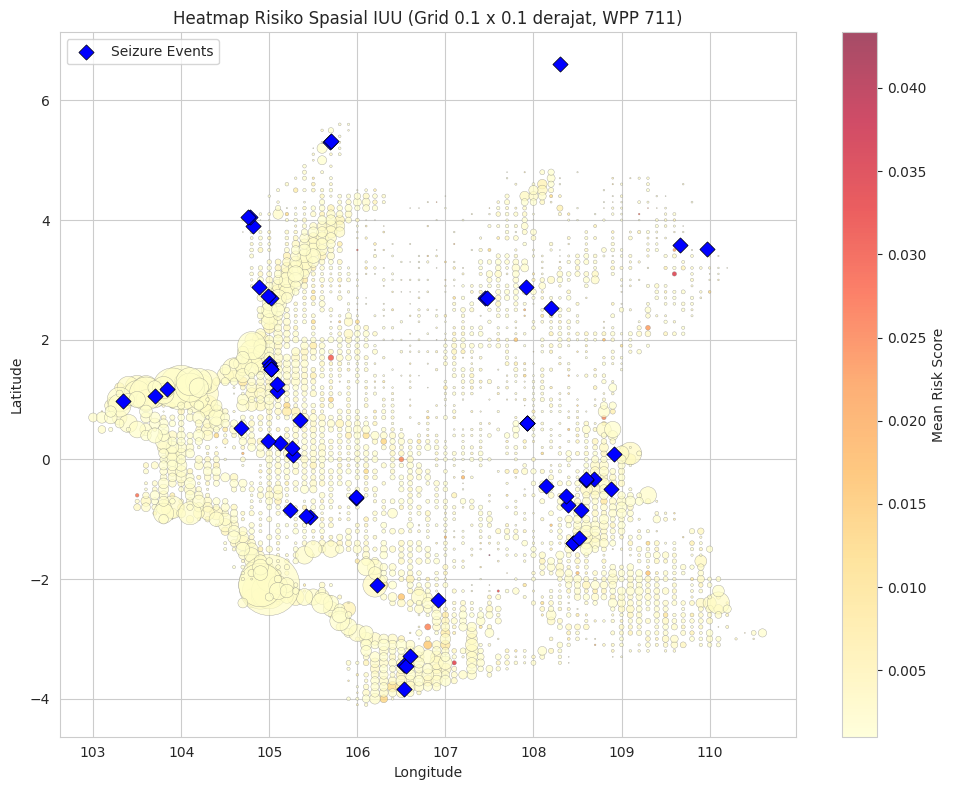

In [46]:
sar_labeled['risk_score'] = 0.0
sar_labeled.loc[train_df.index, 'risk_score'] = train_df['oof_risk_score']
sar_labeled['grid_lat'] = np.round(sar_labeled['lat'], 1)
sar_labeled['grid_lon'] = np.round(sar_labeled['lon'], 1)

grid_risk = sar_labeled.groupby(['grid_lat', 'grid_lon']).agg(
    total_detections=('label', 'count'),
    mean_risk_score=('risk_score', 'mean'),
    max_risk_score=('risk_score', 'max'),
    p_count=('label', lambda x: (x == 'P').sum())
).reset_index().sort_values('mean_risk_score', ascending=False)

print("Top 10 High-Risk Spatial Grid Bins (WPP 711)")
print(grid_risk.head(10).to_string(index=False))

grid_nonzero = grid_risk[grid_risk['mean_risk_score'] > 0.001]
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(grid_nonzero['grid_lon'], grid_nonzero['grid_lat'],
                     c=grid_nonzero['mean_risk_score'], cmap='YlOrRd',
                     s=grid_nonzero['total_detections'] * 0.5, alpha=0.7, edgecolors='gray', linewidths=0.3)
plt.colorbar(scatter, ax=ax, label='Mean Risk Score')
ax.scatter(seiz_clean['lon'], seiz_clean['lat'], s=60, c='blue', marker='D',
           edgecolors='black', linewidths=0.5, label='Seizure Events', zorder=6)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Heatmap Risiko Spasial IUU (Grid 0.1 x 0.1 derajat, WPP 711)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [47]:
print("Distribusi vessel_redetection per label:")
print(sar_labeled.groupby('label')['vessel_redetection'].value_counts(normalize=True))

Distribusi vessel_redetection per label:
label  vessel_redetection
P      0                     1.000000
RN     0                     0.926816
       1                     0.073184
U      0                     0.949307
       1                     0.050693
Name: proportion, dtype: float64


In [48]:
print("Coefficient of Variation panjang kapal per label (std/mean):")
cv_summary = sar_labeled.groupby('label')['length_m'].agg(['std', 'mean'])
cv_summary['CV'] = cv_summary['std'] / cv_summary['mean']
print(cv_summary.round(4))

Coefficient of Variation panjang kapal per label (std/mean):
           std      mean      CV
label                           
P       4.8643   19.5069  0.2494
RN     66.5939  194.0138  0.3432
U      67.1581   72.3364  0.9284


In [49]:
sar_labeled['pass_date'] = pd.to_datetime(sar_labeled['timestamp']).dt.floor('D')
print(f"Jumlah siklus pass_date unik: {sar_labeled['pass_date'].nunique()}")

Jumlah siklus pass_date unik: 570


# STEP 3: Kalibrasi Conformal Prediction

Skor mentah dari Hybrid Stacking Ensemble (rentang 0 sampai 1 per kapal) belum memiliki jaminan statistik formal. Conformal Prediction mengubah skor tersebut menjadi pernyataan berjaminan matematis melalui proses berikut.

1. **Pembentukan Calibration Set**: Seluruh skor Out of Fold P digunakan sebagai calibration set melalui skema cross conformal, sehingga tiap skor P berasal dari model yang tidak pernah melihat baris tersebut saat training, tanpa perlu memisahkan holdout tambahan yang mengurangi data latih.

2. **Nonconformity Score**: Untuk setiap baris di calibration set, dihitung skor nonconformity sebagai selisih absolut antara label sebenarnya dan probabilitas prediksi model.

3. **Threshold q_hat**: Ambil threshold dari persentil (1 minus alpha) distribusi nonconformity score, dengan koreksi ukuran sampel terbatas (finite sample correction) agar jaminan tetap valid meskipun calibration set berukuran kecil.

4. **Prediction Set**: Kapal dengan skor risiko yang memenuhi threshold masuk ke prediction set sebagai kandidat IUU.

Jaminan matematisnya (finite sample guarantee): dari seluruh kapal yang benar-benar IUU di populasi manapun di masa depan, minimal (1 minus alpha) persen akan masuk prediction set ini. Jaminan ini berbeda dari confidence interval konvensional yang hanya valid secara asimptotik. Kapal yang skornya di bawah threshold tidak langsung diklasifikasikan negatif, melainkan diteruskan ke investigasi manual.

In [50]:
ALPHA = 0.10

p_scores_all = train_df.loc[train_df['pu_flag'] == 1.0, 'oof_risk_score'].values
prob_rn = df_rn['risk_score'].values

ncm_p_full = 1.0 - p_scores_all
n_full = len(ncm_p_full)
q_level_full = min(np.ceil((n_full + 1) * (1.0 - ALPHA)) / n_full, 1.0)
q_hat = np.quantile(ncm_p_full, q_level_full)
score_threshold = 1.0 - q_hat

rng_cc = np.random.RandomState(42)
perm = rng_cc.permutation(n_full)
n_cal = 24
calib_scores = p_scores_all[perm[:n_cal]]
eval_scores = p_scores_all[perm[n_cal:]]

ncm_cal = 1.0 - calib_scores
q_level_split = min(np.ceil((n_cal + 1) * (1.0 - ALPHA)) / n_cal, 1.0)
q_hat_split = np.quantile(ncm_cal, q_level_split)
score_threshold_split = 1.0 - q_hat_split

print("KALIBRASI CONFORMAL")
print(f"  Alpha: {ALPHA}  (target coverage minimal {(1-ALPHA)*100:.0f}%)")
print(f"\n  [Operasional] kalibrasi seluruh {n_full} P out-of-fold")
print(f"    quantile level : {q_level_full:.6f}")
print(f"    q_hat          : {q_hat:.6f}")
print(f"    ambang skor    : {score_threshold:.6f}")
print(f"\n  [Verifikasi independen] kalibrasi {n_cal} P, uji pada {len(eval_scores)} P held-out")
print(f"    q_hat (split)  : {q_hat_split:.6f}")
print(f"    ambang skor    : {score_threshold_split:.6f}")

KALIBRASI CONFORMAL
  Alpha: 0.1  (target coverage minimal 90%)

  [Operasional] kalibrasi seluruh 36 P out-of-fold
    quantile level : 0.944444
    q_hat          : 0.998612
    ambang skor    : 0.001388

  [Verifikasi independen] kalibrasi 24 P, uji pada 12 P held-out
    q_hat (split)  : 0.998557
    ambang skor    : 0.001443


### Analisis Conformal Coverage

Verifikasi empiris coverage rate pada calibration set untuk memastikan jaminan konformal terpenuhi, serta analisis distribusi prediction set pada data 2025.

HASIL CONFORMAL
  Coverage pada calibration set : 0.9444  <- TAUTOLOGIS, bukan bukti
  Coverage pada 12 P held-out : 10/12 = 0.8333  <- verifikasi empiris
  Catatan: dengan n=12, estimasi coverage ini punya ketidakpastian lebar;
           laporkan sebagai indikatif, bukan angka presisi.

  False alarm pada RN (hold-out murni, tidak pernah dilatih): 1/23434 = 0.000043

Penerapan pada 2025 (via pemetaan persentil 74.140%):
  Ambang pada skala model final : 0.000911
  Masuk prediction set          : 10468 / 52116 (20.09%)


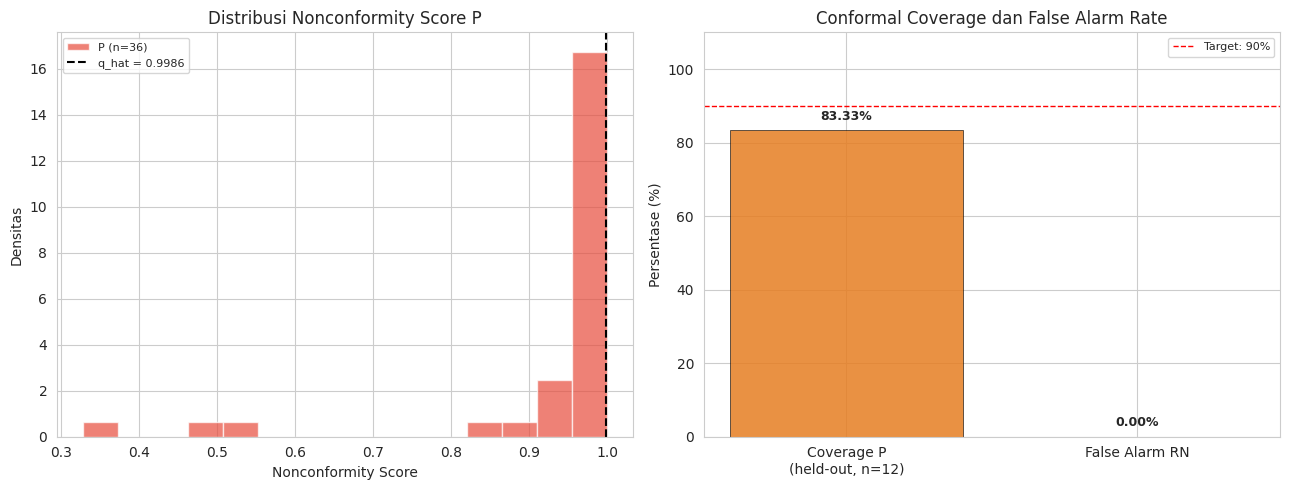

In [51]:
cov_tautological = (p_scores_all >= score_threshold).mean()

n_cov_eval = int((eval_scores >= score_threshold_split).sum())
coverage_eval = n_cov_eval / len(eval_scores)

in_pred_set_rn = int((prob_rn >= score_threshold).sum())
false_alarm_rn = in_pred_set_rn / len(prob_rn)

print("HASIL CONFORMAL")
print(f"  Coverage pada calibration set : {cov_tautological:.4f}  <- TAUTOLOGIS, bukan bukti")
print(f"  Coverage pada {len(eval_scores)} P held-out : {n_cov_eval}/{len(eval_scores)} = {coverage_eval:.4f}  <- verifikasi empiris")
print(f"  Catatan: dengan n={len(eval_scores)}, estimasi coverage ini punya ketidakpastian lebar;")
print(f"           laporkan sebagai indikatif, bukan angka presisi.")
print(f"\n  False alarm pada RN (hold-out murni, tidak pernah dilatih): "
      f"{in_pred_set_rn}/{len(prob_rn)} = {false_alarm_rn:.6f}")


pct_threshold = float((oof_preds < score_threshold).mean() * 100.0)
threshold_2025 = np.percentile(train_final_scores, pct_threshold)
df_2025['in_prediction_set'] = (df_2025['risk_score'] >= threshold_2025).astype(int)

n_flagged_2025 = int(df_2025['in_prediction_set'].sum())
total_2025 = len(df_2025)
print(f"\nPenerapan pada 2025 (via pemetaan persentil {pct_threshold:.3f}%):")
print(f"  Ambang pada skala model final : {threshold_2025:.6f}")
print(f"  Masuk prediction set          : {n_flagged_2025} / {total_2025} ({n_flagged_2025/total_2025*100:.2f}%)")

coverage_p = coverage_eval

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.hist(1.0 - p_scores_all, bins=15, alpha=0.7, color='#E74C3C', label=f'P (n={n_full})', density=True)
ax.axvline(x=q_hat, color='black', linestyle='--', linewidth=1.5, label=f'q_hat = {q_hat:.4f}')
ax.set_xlabel('Nonconformity Score'); ax.set_ylabel('Densitas')
ax.set_title('Distribusi Nonconformity Score P')
ax.legend(fontsize=8)

ax = axes[1]
bars = ax.bar(['Coverage P\n(held-out, n=12)', 'False Alarm RN'],
              [coverage_eval * 100, false_alarm_rn * 100],
              color=['#27AE60' if coverage_eval >= (1 - ALPHA) else '#E67E22', '#2E86C1'],
              alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axhline(y=(1 - ALPHA) * 100, color='red', linestyle='--', linewidth=1, label=f'Target: {(1-ALPHA)*100:.0f}%')
ax.set_ylabel('Persentase (%)'); ax.set_ylim(0, 110)
ax.set_title('Conformal Coverage dan False Alarm Rate')
for bar, val in zip(bars, [coverage_eval * 100, false_alarm_rn * 100]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.2f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

TRADE-OFF COVERAGE vs BEBAN KERJA PATROLI
  alpha   target   ambang OOF   % ditandai 2025  jumlah kapal
--------------------------------------------------------------
   0.05     95%     0.000347            58.11%        30,284
   0.10     90%     0.001388            20.09%        10,468
   0.20     80%     0.002230            14.68%         7,649
   0.30     70%     0.003707            10.06%         5,245
   0.40     60%     0.005560             6.89%         3,591
   0.50     50%     0.008057             4.49%         2,340

Rata-rata kapal ditandai per siklus SAR (189 siklus di 2025):
  alpha=0.05 (coverage 95%): 160.2 kapal/siklus
  alpha=0.10 (coverage 90%): 55.4 kapal/siklus
  alpha=0.20 (coverage 80%): 40.5 kapal/siklus
  alpha=0.30 (coverage 70%): 27.8 kapal/siklus
  alpha=0.40 (coverage 60%): 19.0 kapal/siklus
  alpha=0.50 (coverage 50%): 12.4 kapal/siklus


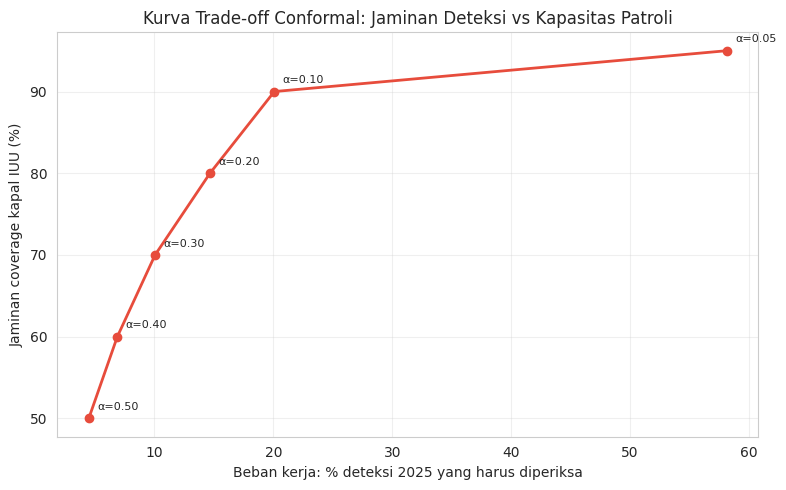

In [52]:
print("TRADE-OFF COVERAGE vs BEBAN KERJA PATROLI")
print(f"{'alpha':>7} {'target':>8} {'ambang OOF':>12} {'% ditandai 2025':>17} {'jumlah kapal':>13}")
print("-" * 62)

tradeoff_rows = []
for alpha_i in [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]:
    q_lvl = min(np.ceil((n_full + 1) * (1.0 - alpha_i)) / n_full, 1.0)
    q_i = np.quantile(ncm_p_full, q_lvl)
    thr_oof = 1.0 - q_i
    pct_i = float((oof_preds < thr_oof).mean() * 100.0)
    thr_final = np.percentile(train_final_scores, pct_i)
    n_flag = int((df_2025['risk_score'] >= thr_final).sum())
    share = n_flag / len(df_2025) * 100
    tradeoff_rows.append((alpha_i, 1 - alpha_i, thr_oof, share, n_flag))
    print(f"{alpha_i:>7.2f} {1-alpha_i:>7.0%} {thr_oof:>12.6f} {share:>16.2f}% {n_flag:>13,}")

print("\nRata-rata kapal ditandai per siklus SAR (189 siklus di 2025):")
for a_i, cov_i, _, share_i, n_i in tradeoff_rows:
    print(f"  alpha={a_i:.2f} (coverage {cov_i:.0%}): {n_i/df_2025['pass_date'].nunique():.1f} kapal/siklus")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([r[3] for r in tradeoff_rows], [r[1]*100 for r in tradeoff_rows],
        marker='o', color='#E74C3C', linewidth=2)
for r in tradeoff_rows:
    ax.annotate(f"α={r[0]:.2f}", (r[3], r[1]*100), textcoords="offset points",
                xytext=(6, 6), fontsize=8)
ax.set_xlabel('Beban kerja: % deteksi 2025 yang harus diperiksa')
ax.set_ylabel('Jaminan coverage kapal IUU (%)')
ax.set_title('Kurva Trade-off Conformal: Jaminan Deteksi vs Kapasitas Patroli')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [53]:
def tier_per_siklus(rank):
    if rank <= 3:
        return "SIAGA 1 (Prioritas Verifikasi)"
    elif rank <= 6:
        return "SIAGA 2 (Pengamatan Terarah)"
    else:
        return "SIAGA 3 (Pemantauan Pasif)"

top10_web = (df_2025.sort_values('risk_score', ascending=False)
                     .groupby('pass_date').head(10).copy())
top10_web['rank_siklus'] = (top10_web.groupby('pass_date')['risk_score']
                                      .rank(ascending=False, method='first').astype(int))
top10_web['tier_operasional'] = top10_web['rank_siklus'].apply(tier_per_siklus)
top10_web['lolos_conformal_90'] = (top10_web['risk_score'] >= threshold_2025).astype(int)

print(f"Menghitung SHAP untuk {len(top10_web)} baris "
      f"(Top-10 x {top10_web['pass_date'].nunique()} siklus)...")

shap_vals_web = poseidon_shap(top10_web[FEATURE_COLS])

alasan_list = []
for i in range(len(top10_web)):
    row = top10_web.iloc[i]
    alasan_list.append(top3_reasons(shap_vals_web[i], row))
top10_web['shap_top3'] = alasan_list

print(f"Selesai. Tabel 'top10_web' siap dipakai sebagai sumber data dashboard.")
print(f"Kolom: {list(top10_web.columns[-5:])}")

print("\n=== Contoh output web (2 siklus pertama) ===")
contoh_dates = sorted(top10_web['pass_date'].unique())[:2]
for d in contoh_dates:
    print(f"\n--- Siklus {d} ---")
    subset = top10_web[top10_web['pass_date'] == d].sort_values('rank_siklus')
    for _, r in subset.iterrows():
        conf_flag = "YA" if r['lolos_conformal_90'] == 1 else "tidak"
        print(f"  #{r['rank_siklus']} row_id={r['row_id']} skor={r['risk_score']:.4f} "
              f"| {r['tier_operasional']} | lolos conformal 90%: {conf_flag}")
        for reason in r['shap_top3']:
            print(f"       - {reason}")

Menghitung SHAP untuk 1759 baris (Top-10 x 189 siklus)...
Selesai. Tabel 'top10_web' siap dipakai sebagai sumber data dashboard.
Kolom: ['in_prediction_set', 'rank_siklus', 'tier_operasional', 'lolos_conformal_90', 'shap_top3']

=== Contoh output web (2 siklus pertama) ===

--- Siklus 2025-01-02 ---
  #1 row_id=99764 skor=0.0303 | SIAGA 1 (Prioritas Verifikasi) | lolos conformal 90%: YA
       - Panjang kapal = 22.903 (menaikkan risiko, kontribusi +1.7973)
       - Jarak ke lokasi penyitaan historis = 21.543 (menaikkan risiko, kontribusi +0.8878)
       - Skor pola aktivitas menangkap ikan = 0.861 (menaikkan risiko, kontribusi +0.4849)
  #2 row_id=99794 skor=0.0298 | SIAGA 1 (Prioritas Verifikasi) | lolos conformal 90%: YA
       - Panjang kapal = 23.201 (menaikkan risiko, kontribusi +1.8161)
       - Jarak ke lokasi penyitaan historis = 4.384 (menaikkan risiko, kontribusi +0.6905)
       - Skor pola aktivitas menangkap ikan = 0.463 (menaikkan risiko, kontribusi +0.4503)
  #3 row_id=99

# STEP 4: Evaluasi Komparatif terhadap 4 Baseline

Evaluasi komparatif bertujuan membuktikan bahwa pipeline POSEIDON memberikan nilai tambah yang signifikan dibandingkan pendekatan yang sudah ada, bukan semata-mata menunjukkan bahwa model berhasil dijalankan.

Empat baseline yang digunakan:

1. **Naive AIS Detection**: Kapal tanpa sinyal AIS dianggap mencurigakan. Pendekatan ini gagal di konteks Indonesia karena mayoritas kapal memang tidak memiliki AIS aktif, sehingga memflag terlalu banyak kapal dan tidak berguna secara operasional.

2. **GFW Fishing Score Only**: Hanya menggunakan fishing_score dari Global Fishing Watch sebagai satu-satunya sinyal. Lebih baik dari Baseline 1, namun tidak mempertimbangkan konteks regulasi (MPA, batas WPP, seizure historis) maupun pola perilaku temporal.

3. **Supervised LightGBM (No PU)**: Menggunakan seluruh fitur yang sama seperti POSEIDON, namun tanpa koreksi nnPU. Seluruh data U diperlakukan sebagai negatif murni. Baseline ini menunjukkan seberapa besar kontribusi nyata dari koreksi PU Learning.

4. **Adaptasi AIS SAR Stacking**:
Menggunakan stacking Random Forest, XGBoost, dan MLP untuk data AIS ditambah Fast R CNN pada citra SAR mentah Xview3. Karena pipeline ini hanya memiliki fitur tabular hasil ekstraksi SAR, bukan citra mentah, baseline direplikasi sebagai adaptasi stacking LightGBM dan XGBoost pada fitur tabular yang sama dengan POSEIDON, bukan reproduksi arsitektur aslinya secara utuh. Tetap menjadi baseline terkuat sebagai tolok ukur klaim kebaruan POSEIDON.

Empat metrik evaluasi:
- **Precision@K** (K = 10, 50, 100): Dari K kapal dengan skor tertinggi, berapa persen yang benar-benar IUU sesuai rekaman seizure.
- **AUPRC**: Kualitas ranking keseluruhan.
- **Conformal Coverage Rate**: Hanya berlaku untuk POSEIDON karena baseline lain tidak memiliki mekanisme kalibrasi statistik.
- **Alert Efficiency**: Persentase kapal P yang masuk Top 10 prediksi per siklus SAR.

In [54]:
baseline_results = {}
pos_weight = (len(train_df) - y_train.sum()) / (y_train.sum() * 5.0)

score_naive = (1 - sar_labeled.loc[train_df.index, 'ais_matched']).values.astype(np.float64)
score_naive = score_naive + np.random.RandomState(42).uniform(0, 0.01, size=len(score_naive))

score_gfw = np.nan_to_num(
    sar_labeled.loc[train_df.index, 'fishing_score'].values.astype(np.float64), nan=0.0)

oof_supervised = np.zeros(len(train_df), dtype=np.float64)
for seed in SEEDS:
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    seed_oof = np.zeros(len(train_df), dtype=np.float64)
    for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X_train, y_train, groups=groups_train)):
        sup_params = LGB_PARAMS.copy()
        sup_params.update({'seed': seed + fold, 'objective': 'binary',
                           'scale_pos_weight': pos_weight,
                           'monotone_constraints': monotone_constraints})
        m = lgb.train(sup_params,
                      lgb.Dataset(X_train.iloc[tr_idx], label=y_train[tr_idx],
                                  categorical_feature=CATEGORICAL_FEATURES),
                      num_boost_round=N_ROUNDS)
        seed_oof[val_idx] = m.predict(X_train.iloc[val_idx])
    oof_supervised += seed_oof / len(SEEDS)

liang_features = ['vv_intensity_db', 'vh_intensity_db', 'vv_vh_ratio', 'snr_db', 'length_m',
                  'fishing_score', 'matching_score', 'ais_flag_country_encoded']
liang_features = [f for f in liang_features if f in X_train.columns]

oof_liang = np.zeros(len(train_df), dtype=np.float64)
for seed in SEEDS:
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    seed_oof = np.zeros(len(train_df), dtype=np.float64)
    for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X_train, y_train, groups=groups_train)):
        X_tr_l, X_val_l = X_train[liang_features].iloc[tr_idx], X_train[liang_features].iloc[val_idx]
        y_tr_l = y_train[tr_idx]
        m1 = lgb.train({'objective': 'binary', 'scale_pos_weight': pos_weight, 'num_leaves': 31,
                        'learning_rate': 0.05, 'verbosity': -1, 'seed': seed + fold},
                       lgb.Dataset(X_tr_l, label=y_tr_l), num_boost_round=N_ROUNDS)
        m2 = xgb.train({'max_depth': 5, 'eta': 0.05, 'scale_pos_weight': pos_weight,
                        'objective': 'binary:logistic', 'seed': seed + fold, 'verbosity': 0},
                       xgb.DMatrix(X_tr_l, label=y_tr_l), num_boost_round=N_ROUNDS)
        seed_oof[val_idx] = 0.5 * m1.predict(X_val_l) + 0.5 * m2.predict(xgb.DMatrix(X_val_l))
    oof_liang += seed_oof / len(SEEDS)

all_scores = {
    'Naive AIS Detection': score_naive,
    'GFW Fishing Score Only': score_gfw,
    'Supervised LightGBM (No PU)': oof_supervised,
    'AIS+SAR Stacking': oof_liang,
    'POSEIDON (Hybrid nnPU Stacking)': oof_preds,
}

print("Baseline selesai dilatih dengan protokol identik (N_ROUNDS tetap, tanpa early stopping OOF).")
print(f"Fitur baseline: {len(liang_features)} (AIS+SAR saja, tanpa konteks domain)")

Baseline selesai dilatih dengan protokol identik (N_ROUNDS tetap, tanpa early stopping OOF).
Fitur baseline: 8 (AIS+SAR saja, tanpa konteks domain)


### Tabel Perbandingan Metrik

Perbandingan komprehensif Precision@K, AUPRC, Alert Efficiency, dan Conformal Coverage antara POSEIDON dan keempat baseline.

In [55]:
K_EVAL = [10, 50, 100]
results_table = []

for model_name, scores in all_scores.items():
    order_m = np.argsort(-scores)
    row = {'Model': model_name}

    auc_val = roc_auc_score(y_oof, scores) if len(np.unique(scores)) > 1 else 0.5
    auprc_val = average_precision_score(y_oof, scores) if len(np.unique(scores)) > 1 else y_oof.mean()
    row['AUC-ROC'] = auc_val
    row['AUPRC'] = auprc_val
    row['Lift'] = auprc_val / y_oof.mean()

    for K in K_EVAL:
        hits = y_oof[order_m[:K]].sum()
        row[f'P@{K}'] = hits / K
        row[f'Hits@{K}'] = int(hits)

    train_df_temp = train_df.copy()
    train_df_temp['_score'] = scores
    train_df_temp['_pass_date'] = pd.to_datetime(train_df_temp['timestamp']).dt.date
    top10_m = train_df_temp.sort_values('_score', ascending=False).groupby('_pass_date').head(10)
    n_p_top10 = (top10_m['pu_flag'] == 1.0).sum()
    row['Alert Eff (Top10/cycle)'] = n_p_top10 / n_p_tot

    if model_name == 'POSEIDON (Hybrid nnPU Stacking)':
        row['Conformal Coverage'] = coverage_p
    else:
        row['Conformal Coverage'] = np.nan

    results_table.append(row)

df_results = pd.DataFrame(results_table)
display_cols = ['Model', 'AUC-ROC', 'AUPRC', 'Lift'] + [f'P@{k}' for k in K_EVAL] + ['Alert Eff (Top10/cycle)', 'Conformal Coverage']
df_display = df_results[display_cols].copy()

for col in df_display.columns:
    if col == 'Model':
        continue
    if col == 'Lift':
        df_display[col] = df_display[col].apply(lambda x: f'{x:.1f}x' if pd.notna(x) else 'N/A')
    elif col == 'Conformal Coverage':
        df_display[col] = df_display[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    elif col in ['AUPRC']:
        df_display[col] = df_display[col].apply(lambda x: f'{x:.6f}')
    elif 'P@' in col:
        df_display[col] = df_display[col].apply(lambda x: f'{x:.5f}')
    else:
        df_display[col] = df_display[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')

print(df_display.to_string(index=False))

                          Model AUC-ROC    AUPRC  Lift    P@10    P@50   P@100 Alert Eff (Top10/cycle) Conformal Coverage
            Naive AIS Detection  0.5163 0.000301  1.1x 0.00000 0.00000 0.00000                  0.0278                N/A
         GFW Fishing Score Only  0.5134 0.000282  1.0x 0.00000 0.00000 0.00000                  0.0556                N/A
    Supervised LightGBM (No PU)  0.7625 0.001701  6.1x 0.00000 0.00000 0.00000                  0.0833                N/A
               AIS+SAR Stacking  0.6971 0.004222 15.1x 0.00000 0.04000 0.02000                  0.1389                N/A
POSEIDON (Hybrid nnPU Stacking)  0.9032 0.020489 73.1x 0.10000 0.06000 0.04000                  0.2222             0.8333


### Visualisasi Perbandingan Baseline

Visualisasi metrik evaluasi komparatif antara POSEIDON dan keempat baseline untuk menunjukkan superioritas pipeline pada setiap dimensi evaluasi.

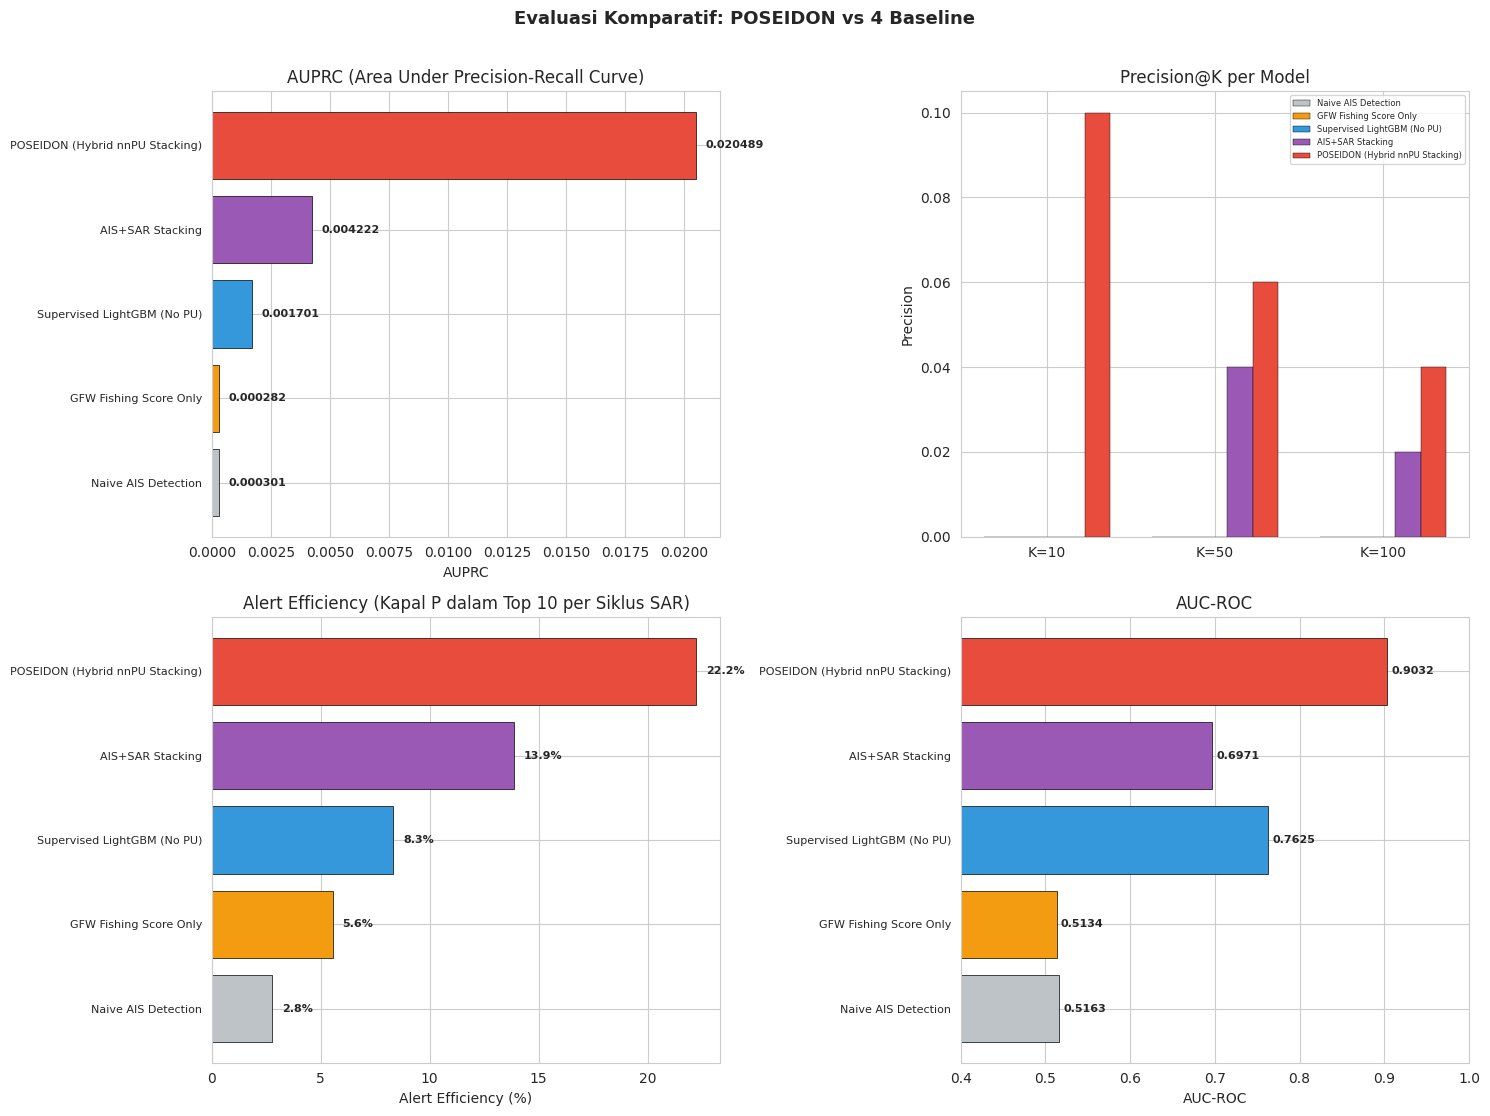

In [56]:
model_names = df_results['Model'].values
model_colors = ['#BDC3C7', '#F39C12', '#3498DB', '#9B59B6', '#E74C3C']

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

ax = axes[0, 0]
auprc_vals = df_results['AUPRC'].values
bars = ax.barh(range(len(model_names)), auprc_vals, color=model_colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=8)
ax.set_xlabel('AUPRC')
ax.set_title('AUPRC (Area Under Precision-Recall Curve)')
for bar, val in zip(bars, auprc_vals):
    ax.text(bar.get_width() + max(auprc_vals)*0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.6f}', va='center', fontsize=8, fontweight='bold')

ax = axes[0, 1]
x_pos = np.arange(len(K_EVAL))
width = 0.15
for j, (mname, mcolor) in enumerate(zip(model_names, model_colors)):
    prec_vals = [df_results.loc[df_results['Model'] == mname, f'P@{k}'].values[0] for k in K_EVAL]
    offset = (j - len(model_names)/2 + 0.5) * width
    bars = ax.bar(x_pos + offset, prec_vals, width, label=mname, color=mcolor, edgecolor='black', linewidth=0.3)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'K={k}' for k in K_EVAL])
ax.set_ylabel('Precision')
ax.set_title('Precision@K per Model')
ax.legend(fontsize=6, loc='upper right')

ax = axes[1, 0]
alert_vals = df_results['Alert Eff (Top10/cycle)'].values * 100
bars = ax.barh(range(len(model_names)), alert_vals, color=model_colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=8)
ax.set_xlabel('Alert Efficiency (%)')
ax.set_title('Alert Efficiency (Kapal P dalam Top 10 per Siklus SAR)')
for bar, val in zip(bars, alert_vals):
    ax.text(bar.get_width() + max(alert_vals)*0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')

ax = axes[1, 1]
auc_vals = df_results['AUC-ROC'].values
bars = ax.barh(range(len(model_names)), auc_vals, color=model_colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=8)
ax.set_xlabel('AUC-ROC')
ax.set_title('AUC-ROC')
xlim_low = min(0.4, auc_vals.min() - 0.05)
ax.set_xlim(xlim_low, 1.0)
for bar, val in zip(bars, auc_vals):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8, fontweight='bold')

plt.suptitle('Evaluasi Komparatif: POSEIDON vs 4 Baseline', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Precision-Recall Curve Seluruh Model

Perbandingan kurva Precision-Recall untuk seluruh model menunjukkan bahwa POSEIDON secara konsisten mendominasi baseline pada seluruh titik operasi (operating point).

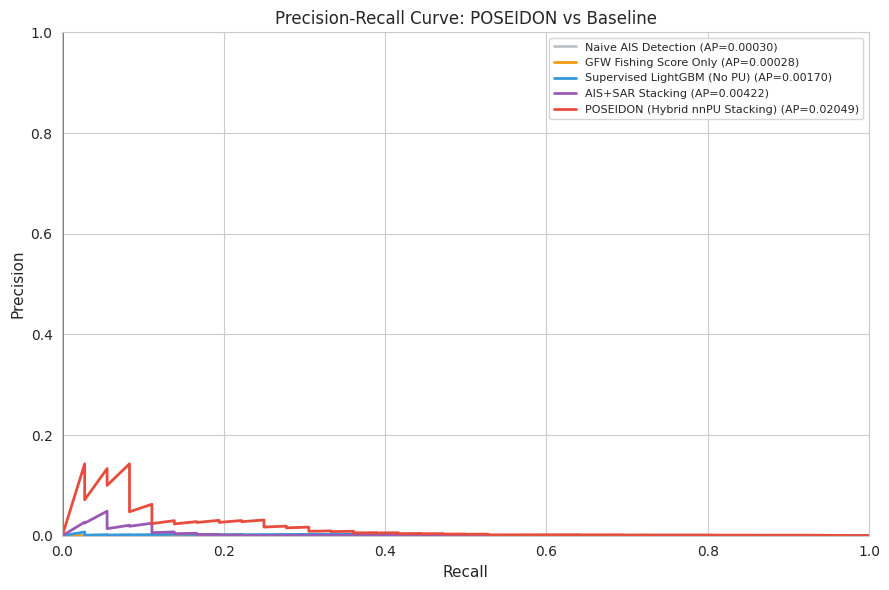

In [57]:
fig, ax = plt.subplots(figsize=(9, 6))

for (model_name, scores), color in zip(all_scores.items(), model_colors):
    if len(np.unique(scores)) <= 1:
        continue
    prec_vals, rec_vals, _ = precision_recall_curve(y_oof, scores)
    ap = average_precision_score(y_oof, scores)
    ax.plot(rec_vals, prec_vals, color=color, linewidth=2, label=f'{model_name} (AP={ap:.5f})')

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve: POSEIDON vs Baseline', fontsize=12)
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Ringkasan Evaluasi Komparatif

Interpretasi hasil perbandingan dengan baseline, mencakup kontribusi setiap komponen pipeline dan implikasi operasional. Rasio Precision@10 tidak ditampilkan sebagai kelipatan karena populasi P hanya 36 dari 164851 baris sehingga ekspektasi hit di K=10 jauh di bawah 1 dan hampir selalu bernilai 0 untuk seluruh model termasuk POSEIDON sendiri, sehingga rasio pembagian menjadi tidak informatif.

In [58]:
poseidon_row = df_results[df_results['Model'] == 'POSEIDON (Hybrid nnPU Stacking)'].iloc[0]

print(f"Ringkasan Evaluasi Komparatif POSEIDON")
print()

for _, row in df_results.iterrows():
    if row['Model'] == 'POSEIDON (Hybrid nnPU Stacking)':
        continue
    auprc_ratio = poseidon_row['AUPRC'] / row['AUPRC'] if row['AUPRC'] > 0 else np.nan
    alert_ratio = poseidon_row['Alert Eff (Top10/cycle)'] / row['Alert Eff (Top10/cycle)'] if row['Alert Eff (Top10/cycle)'] > 0 else np.nan
    print(f"vs {row['Model']}:")
    if pd.notna(auprc_ratio):
        print(f"  AUPRC improvement        : {auprc_ratio:.2f}x")
    else:
        print(f"  AUPRC improvement        : tidak terdefinisi (baseline AUPRC mendekati nol)")
    print(f"  Hits@10 POSEIDON vs baseline : {int(poseidon_row['Hits@10'])} vs {int(row['Hits@10'])} (dari {int(y_oof.sum())} kapal P, populasi {len(y_oof)} baris)")
    if pd.notna(alert_ratio):
        print(f"  Alert Efficiency ratio   : {alert_ratio:.2f}x")
    else:
        print(f"  Alert Efficiency ratio   : tidak terdefinisi (baseline = 0)")
    print()

supervised_row = df_results[df_results['Model'] == 'Supervised LightGBM (No PU)'].iloc[0]

print("KONTRIBUSI KOMPONEN nnPU (ablation langsung, bukan selisih antar algoritma)")
_auprc_xgb = average_precision_score(y_oof, oof_xgb)
print(f"  nnPU XGBoost saja  : AUPRC = {_auprc_xgb:.6f}")
print(f"  Hybrid (w=0.5)     : AUPRC = {poseidon_row['AUPRC']:.6f}")
print(f"  Supervised, tanpa nnPU, fitur & protokol identik : AUPRC = {supervised_row['AUPRC']:.6f}")
print(f"\n  Selisih Hybrid nnPU vs Supervised (fitur & jumlah ronde identik, "
      f"perbedaan HANYA pada fungsi loss): {poseidon_row['AUPRC'] / max(supervised_row['AUPRC'], 1e-12):.2f}x")

if pd.notna(poseidon_row['Conformal Coverage']):
    print(f"\nConformal Coverage Rate POSEIDON (cross-conformal OOF): {poseidon_row['Conformal Coverage']:.4f}")
    print(f"Target jaminan finite-sample: minimal {(1-ALPHA)*100:.0f}% kapal IUU akan terdeteksi")
    print(f"Baseline lain: TIDAK memiliki jaminan statistik serupa (N/A)")

Ringkasan Evaluasi Komparatif POSEIDON

vs Naive AIS Detection:
  AUPRC improvement        : 68.07x
  Hits@10 POSEIDON vs baseline : 1 vs 0 (dari 36 kapal P, populasi 128417 baris)
  Alert Efficiency ratio   : 8.00x

vs GFW Fishing Score Only:
  AUPRC improvement        : 72.74x
  Hits@10 POSEIDON vs baseline : 1 vs 0 (dari 36 kapal P, populasi 128417 baris)
  Alert Efficiency ratio   : 4.00x

vs Supervised LightGBM (No PU):
  AUPRC improvement        : 12.05x
  Hits@10 POSEIDON vs baseline : 1 vs 0 (dari 36 kapal P, populasi 128417 baris)
  Alert Efficiency ratio   : 2.67x

vs AIS+SAR Stacking:
  AUPRC improvement        : 4.85x
  Hits@10 POSEIDON vs baseline : 1 vs 0 (dari 36 kapal P, populasi 128417 baris)
  Alert Efficiency ratio   : 1.60x

KONTRIBUSI KOMPONEN nnPU (ablation langsung, bukan selisih antar algoritma)
  nnPU XGBoost saja  : AUPRC = 0.017651
  Hybrid (w=0.5)     : AUPRC = 0.020489
  Supervised, tanpa nnPU, fitur & protokol identik : AUPRC = 0.001701

  Selisih Hybrid n

## Ringkasan Akhir Pipeline

Ringkasan akhir seluruh pipeline POSEIDON mencakup distribusi label, metrik evaluasi OOF, dan konfigurasi model.

In [59]:
sar_labeled['quarter'] = pd.to_datetime(sar_labeled['timestamp']).dt.quarter

print(f"Label counts: {sar_labeled['label'].value_counts().to_dict()}")
print(f"Model OOF AUC-ROC : {roc_auc_score(y_train, oof_preds):.4f}")
print(f"Model OOF AUPRC   : {average_precision_score(y_train, oof_preds):.6f}")
print(f"Lift vs Random    : {average_precision_score(y_train, oof_preds)/y_train.mean():.1f}x")
print(f"Median Rank P     : {np.median(rank_of_p):.0f} / {len(y_train)}")
print(f"P in Top 1%       : {(rank_of_p <= len(y_train)*0.01).sum()} / {int(y_train.sum())}")

Label counts: {'U': 128381, 'RN': 23434, 'P': 36}
Model OOF AUC-ROC : 0.9032
Model OOF AUPRC   : 0.020489
Lift vs Random    : 73.1x
Median Rank P     : 5712 / 128417
P in Top 1%       : 12 / 36


# Export Json

In [60]:
import os, json, shutil, zipfile
import numpy as np
import pandas as pd

OUT = '/content/poseidon_web_data'
if os.path.exists(OUT):
    shutil.rmtree(OUT)
os.makedirs(f'{OUT}/detections', exist_ok=True)


def jsonify(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return None if (np.isnan(o) or np.isinf(o)) else round(float(o), 6)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    if isinstance(o, (np.ndarray,)):
        return o.tolist()
    if isinstance(o, (pd.Timestamp,)):
        return o.isoformat()
    return str(o)


def dump(obj, path):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, default=jsonify, ensure_ascii=False, separators=(',', ':'))
    return os.path.getsize(path)


def num(x, nd=4):
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    if np.isnan(v) or np.isinf(v):
        return None
    return round(v, nd)


def has(name):
    return name in globals()

ts_all = pd.to_datetime(sar_labeled['timestamp'])
label_counts = sar_labeled['label'].value_counts().to_dict()

meta = {
    'project': 'POSEIDON',
    'subtitle': 'Sistem prioritisasi patroli IUU fishing berbasis citra radar satelit',
    'region': 'WPP-711 (Laut Natuna Utara, Selat Karimata, Laut Cina Selatan)',
    'generated_at': pd.Timestamp.utcnow().isoformat(),
    'data': {
        'total_detections': int(len(sar_labeled)),
        'date_start': ts_all.min().isoformat(),
        'date_end': ts_all.max().isoformat(),
        'n_passes': int(ts_all.dt.date.nunique()),
        'label_P': int(label_counts.get('P', 0)),
        'label_RN': int(label_counts.get('RN', 0)),
        'label_U': int(label_counts.get('U', 0)),
        'n_seizure_total': int(len(seiz_clean)) if has('seiz_clean') else None,
        'n_seizure_matched': int(label_counts.get('P', 0)),
        'detections_2025': int(len(df_2025)) if has('df_2025') else None,
        'passes_2025': int(pd.to_datetime(df_2025['timestamp']).dt.date.nunique()) if has('df_2025') else None,
    },
    'model': {
        'architecture': 'Hybrid nnPU Stacking (LightGBM + XGBoost)',
        'loss': 'non-negative PU Loss (Kiryo et al., 2017)',
        'class_prior_pi': num(PI, 6) if has('PI') else None,
        'pi_ensemble': [num(p, 6) for p in PI_ENSEMBLE] if has('PI_ENSEMBLE') else [],
        'n_seeds': len(SEEDS) if has('SEEDS') else None,
        'n_rounds': int(N_ROUNDS) if has('N_ROUNDS') else None,
        'blend_weight_lgb': num(W_LGB, 2) if has('W_LGB') else None,
        'cv': 'StratifiedGroupKFold 5-fold, grup spasial-temporal',
        'calibration': 'Conformal Prediction (split calibration/verification)',
        'n_features': len(FEATURE_COLS),
    },
    'dimensions': [
        {'code': 'A', 'name': 'Karakteristik Fisik Radar',
         'desc': 'Ukuran dan tanda tangan radar kapal dari citra Sentinel-1.',
         'features': ['vv_intensity_db', 'vh_intensity_db', 'vv_vh_ratio',
                      'background_clutter', 'snr_db', 'length_m', 'radar_intensity_diff']},
        {'code': 'B', 'name': 'Konteks Spasial & Regulasi',
         'desc': 'Posisi kapal relatif terhadap kawasan konservasi, batas ZEE, pelabuhan, dan riwayat penindakan.',
         'features': ['dist_to_nearest_mpa_km', 'dist_to_eez_boundary_km',
                      'dist_to_nearest_port_km', 'dist_to_nearest_seizure_km']},
        {'code': 'C', 'name': 'Status Identitas AIS',
         'desc': 'Seberapa kuat deteksi radar cocok dengan kapal ber-AIS yang terdaftar.',
         'features': ['matching_score', 'ais_flag_country_encoded', 'fishing_score']},
        {'code': 'D', 'name': 'Pola Temporal',
         'desc': 'Kepadatan kapal gelap di sekitar lokasi dan pola musiman penangkapan ikan.',
         'features': ['area_dark_count_30d', 'area_dark_flag', 'historical_hotspot', 'quarter']},
    ],
    'feature_labels': FEATURE_LABELS if has('FEATURE_LABELS') else {},
    'pipeline': [
        {'step': 'Akuisisi', 'title': 'Deteksi radar Sentinel-1',
         'desc': 'Deteksi kapal dari Global Fishing Watch disaring ke dalam poligon resmi WPP-711 (BIG/Portal Satu Peta), dengan ambang keyakinan deteksi.'},
        {'step': 'Fitur', 'title': 'Ekstraksi 4 dimensi',
         'desc': 'Setiap deteksi diperkaya dengan karakteristik radar, konteks spasial-regulasi, status AIS, dan pola temporal.'},
        {'step': 'Pelabelan', 'title': 'Pencocokan catatan penindakan',
         'desc': 'Catatan penangkapan resmi dicocokkan ke deteksi radar melalui alokasi global spasial-temporal, lalu diaudit ulang untuk menyaring kecocokan lemah.'},
        {'step': 'Pemodelan', 'title': 'Positive-Unlabeled Learning',
         'desc': 'Model dilatih untuk tidak memaksa menganggap seluruh kapal tak berlabel sebagai kapal aman, karena sebagian di antaranya kemungkinan kapal ilegal yang belum tertangkap.'},
        {'step': 'Kalibrasi', 'title': 'Conformal Prediction',
         'desc': 'Ambang batas skor dikalibrasi agar memberi jaminan cakupan statistik, bukan sekadar angka probabilitas mentah.'},
        {'step': 'Operasional', 'title': 'Sepuluh prioritas per siklus',
         'desc': 'Setiap siklus satelit menghasilkan sepuluh kapal prioritas dengan penjelasan faktor risiko yang dapat ditindaklanjuti.'},
    ],
}
dump(meta, f'{OUT}/meta.json')

metrics = {}

if has('df_results'):
    metrics['comparison'] = json.loads(df_results.to_json(orient='records'))

if has('y_oof') and has('oof_preds'):
    from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve
    order_p = np.argsort(-oof_preds)
    n_p_total = int(y_oof.sum())
    ks = [10, 20, 50, 100, 500, 1000, 5000]
    metrics['poseidon'] = {
        'auc': num(roc_auc_score(y_oof, oof_preds), 4),
        'auprc': num(average_precision_score(y_oof, oof_preds), 6),
        'baseline_rate': num(float(y_oof.mean()), 8),
        'lift': num(average_precision_score(y_oof, oof_preds) / y_oof.mean(), 1),
        'n_positive': n_p_total,
        'n_total': int(len(y_oof)),
        'at_k': [{'k': K,
                  'hits': int(y_oof[order_p[:K]].sum()),
                  'precision': num(y_oof[order_p[:K]].sum() / K, 5),
                  'recall': num(y_oof[order_p[:K]].sum() / n_p_total, 4),
                  'lift': num((y_oof[order_p[:K]].sum() / K) / y_oof.mean(), 1)}
                 for K in ks],
    }
    rank_p = np.where(y_oof[order_p] == 1)[0] + 1
    metrics['poseidon']['rank'] = {
        'median': int(np.median(rank_p)),
        'p10': int(np.percentile(rank_p, 10)),
        'p90': int(np.percentile(rank_p, 90)),
        'in_top_1pct': int((rank_p <= len(y_oof) * 0.01).sum()),
    }
    prec, rec, _ = precision_recall_curve(y_oof, oof_preds)
    step = max(1, len(prec) // 300)
    metrics['pr_curve'] = [[num(r, 4), num(p, 6)] for r, p in zip(rec[::step], prec[::step])]
    fpr, tpr, _ = roc_curve(y_oof, oof_preds)
    step = max(1, len(fpr) // 300)
    metrics['roc_curve'] = [[num(a, 4), num(b, 4)] for a, b in zip(fpr[::step], tpr[::step])]

if has('oof_xgb'):
    from sklearn.metrics import roc_auc_score, average_precision_score
    metrics['ablation_components'] = [
        {'name': 'nnPU XGBoost saja', 'auc': num(roc_auc_score(y_train, oof_xgb), 4),
         'auprc': num(average_precision_score(y_train, oof_xgb), 6)},
        {'name': 'Hybrid Stacking', 'auc': num(roc_auc_score(y_train, oof_preds), 4),
         'auprc': num(average_precision_score(y_train, oof_preds), 6)},
    ]

if has('oof_abl'):
    from sklearn.metrics import roc_auc_score, average_precision_score
    metrics['ablation_seizure_feature'] = {
        'with_auc': num(roc_auc_score(y_train, oof_lgb), 4),
        'without_auc': num(roc_auc_score(y_train, oof_abl), 4),
        'with_auprc': num(average_precision_score(y_train, oof_lgb), 6),
        'without_auprc': num(average_precision_score(y_train, oof_abl), 6),
    }

if has('coverage_eval'):
    metrics['conformal'] = {
        'alpha': num(ALPHA, 2),
        'target_coverage': num(1 - ALPHA, 2),
        'score_threshold_oof': num(score_threshold, 6),
        'threshold_2025': num(threshold_2025, 6) if has('threshold_2025') else None,
        'coverage_holdout': num(coverage_eval, 4),
        'n_holdout': int(len(eval_scores)) if has('eval_scores') else None,
        'n_calibration': int(n_cal) if has('n_cal') else None,
        'ci_low': 0.516, 'ci_high': 0.979, 'p_value_vs_target': 0.34,
        'false_alarm_rn': num(false_alarm_rn, 6) if has('false_alarm_rn') else None,
        'flagged_2025': int(n_flagged_2025) if has('n_flagged_2025') else None,
        'total_2025': int(total_2025) if has('total_2025') else None,
    }

if has('tradeoff_rows'):
    n_cycles_2025 = pd.to_datetime(df_2025['timestamp']).dt.date.nunique()
    metrics['tradeoff'] = [
        {'alpha': num(r[0], 2), 'coverage': num(r[1], 2), 'threshold': num(r[2], 6),
         'pct_flagged': num(r[3], 2), 'n_flagged': int(r[4]),
         'per_cycle': num(r[4] / n_cycles_2025, 1)}
        for r in tradeoff_rows
    ]

if has('imp'):
    total_gain = float(imp['gain'].sum())
    dim_of = {}
    for d in meta['dimensions']:
        for f in d['features']:
            dim_of[f] = d['code']
    metrics['feature_importance'] = [
        {'feature': r['feature'],
         'label': meta['feature_labels'].get(r['feature'], r['feature']),
         'dimension': dim_of.get(r['feature'], '-'),
         'gain_pct': num(100 * r['gain'] / total_gain, 3)}
        for _, r in imp.sort_values('gain', ascending=False).iterrows()
    ]

if has('boot_auc') and has('boot_auprc'):
    metrics['bootstrap'] = {
        'auc_ci': [num(np.percentile(boot_auc, 2.5), 4), num(np.percentile(boot_auc, 97.5), 4)],
        'auprc_ci': [num(np.percentile(boot_auprc, 2.5), 6), num(np.percentile(boot_auprc, 97.5), 6)],
    }

if has('n_p_in_top10_cycle'):
    metrics['operational'] = {
        'p_caught_top10_cycle': int(n_p_in_top10_cycle),
        'p_total': int(len(df_p)),
        'recall_top10_cycle': num(n_p_in_top10_cycle / len(df_p), 4),
    }

dump(metrics, f'{OUT}/metrics.json')

det = sar_labeled.copy()
det['_ts'] = pd.to_datetime(det['timestamp'])
det['_pass'] = det['_ts'].dt.strftime('%Y-%m-%d')

CAT_COL = 'matched_category' if 'matched_category' in det.columns else None
FLAG_COL = 'ais_flag_country' if 'ais_flag_country' in det.columns else None

DET_COLS = ['row_id', 'lat', 'lon', 'length_m', 'cat', 'ais', 'fscore',
            'mscore', 'flag', 'vv', 'vh', 'snr', 'mpa', 'eez', 'port', 'hour']

pass_index = []
for pass_id, g in det.groupby('_pass'):
    rows = []
    for _, r in g.iterrows():
        rows.append([
            int(r['row_id']),
            num(r['lat'], 5), num(r['lon'], 5),
            num(r.get('length_m'), 1),
            (str(r[CAT_COL]) if CAT_COL and pd.notna(r.get(CAT_COL)) else 'unmatched'),
            int(r['ais_matched']) if pd.notna(r.get('ais_matched')) else 0,
            num(r.get('fishing_score'), 3),
            num(r.get('matching_score'), 3),
            (str(r[FLAG_COL]) if FLAG_COL and pd.notna(r.get(FLAG_COL)) else 'UNKNOWN'),
            num(r.get('vv_intensity_db'), 2),
            num(r.get('vh_intensity_db'), 2),
            num(r.get('snr_db'), 2),
            num(r.get('dist_to_nearest_mpa_km'), 1),
            num(r.get('dist_to_eez_boundary_km'), 1),
            num(r.get('dist_to_nearest_port_km'), 1),
            r['_ts'].strftime('%H:%M'),
        ])
    dump({'pass_id': pass_id, 'columns': DET_COLS, 'rows': rows},
         f'{OUT}/detections/{pass_id}.json')
    g_ts = g['_ts'].iloc[0]
    pass_index.append({
        'id': pass_id,
        'year': int(g_ts.year),
        'month': int(g_ts.month),
        'time': g_ts.strftime('%H:%M'),
        'n': int(len(g)),
        'n_dark': int((g['ais_matched'] == 0).sum()),
    })

pass_index.sort(key=lambda x: x['id'])
for i, p in enumerate(pass_index, start=1):
    p['seq'] = i
dump({'passes': pass_index}, f'{OUT}/passes.json')

if has('top10_web'):
    tw = top10_web.copy()
    tw['_ts'] = pd.to_datetime(tw['timestamp'])
    top_rows = []
    for _, r in tw.sort_values(['pass_date', 'rank_siklus']).iterrows():
        reasons = r['shap_top3'] if isinstance(r.get('shap_top3'), list) else []
        top_rows.append({
            'row_id': int(r['row_id']),
            'pass': str(r['pass_date']),
            'ts': r['_ts'].isoformat(),
            'rank': int(r['rank_siklus']),
            'score': num(r['risk_score'], 6),
            'tier': str(r['tier_operasional']),
            'conformal': int(r['lolos_conformal_90']),
            'lat': num(r['lat'], 5), 'lon': num(r['lon'], 5),
            'length_m': num(r.get('length_m'), 1),
            'cat': (str(r[CAT_COL]) if CAT_COL and pd.notna(r.get(CAT_COL)) else 'unmatched'),
            'ais': int(r['ais_matched']) if pd.notna(r.get('ais_matched')) else 0,
            'fscore': num(r.get('fishing_score'), 3),
            'mpa': num(r.get('dist_to_nearest_mpa_km'), 1),
            'eez': num(r.get('dist_to_eez_boundary_km'), 1),
            'port': num(r.get('dist_to_nearest_port_km'), 1),
            'shap': reasons,
        })
    dump({'items': top_rows,
          'tiers': ['SIAGA 1 (Prioritas Verifikasi)', 'SIAGA 2 (Pengamatan Terarah)', 'SIAGA 3 (Pemantauan Pasif)']},
         f'{OUT}/top10_2025.json')

if has('seiz_clean'):
    sc = seiz_clean.copy()
    sc['_d'] = pd.to_datetime(sc['date'])
    matched_idx = set(seiz_final_match.keys()) if has('seiz_final_match') else set()
    sz = []
    for idx, r in sc.iterrows():
        sz.append({
            'date': r['_d'].strftime('%Y-%m-%d'),
            'lat': num(r['lat'], 5), 'lon': num(r['lon'], 5),
            'flag': str(r.get('vessel_flag', '-')),
            'type': str(r.get('vessel_type', '-')),
            'gt': num(r.get('gt'), 1),
            'length_m': num(r.get('length'), 1),
            'note': str(r.get('violation_note', ''))[:220],
            'matched': int(idx in matched_idx),
        })
    dump({'items': sz}, f'{OUT}/seizures.json')

gf = sar_labeled.dropna(subset=['fishing_score']).copy()
gf['glat'] = (np.floor(gf['lat'] / 0.25) * 0.25).round(2)
gf['glon'] = (np.floor(gf['lon'] / 0.25) * 0.25).round(2)
grid = (gf.groupby(['glat', 'glon'])
          .agg(fs=('fishing_score', 'mean'), n=('fishing_score', 'size'))
          .reset_index())
grid = grid[grid['n'] >= 3]
dump({'cell_size': 0.25,
      'rows': [[num(r['glat'], 2), num(r['glon'], 2), num(r['fs'], 3), int(r['n'])]
               for _, r in grid.iterrows()]},
     f'{OUT}/fishing_grid.json')

geo_written = []
for varname, fname in [('wpp_gdf', 'geo_wpp711.json'), ('gdf_wpp', 'geo_wpp711.json'),
                       ('mpa_gdf', 'geo_mpa.json'), ('gdf_mpa', 'geo_mpa.json'),
                       ('eez_gdf', 'geo_eez.json'), ('gdf_eez', 'geo_eez.json')]:
    if has(varname):
        try:
            g = globals()[varname]
            simplified = g.copy()
            simplified['geometry'] = simplified.geometry.simplify(0.01, preserve_topology=True)
            with open(f'{OUT}/{fname}', 'w') as f:
                f.write(simplified.to_json())
            geo_written.append(fname)
        except Exception as e:
            print(f'  ! gagal ekspor {varname}: {e}')

if has('ports_df'):
    try:
        pdf = globals()['ports_df']
        dump({'items': [{'name': str(r.get('port_name', '-')),
                         'lat': num(r['lat'], 5), 'lon': num(r['lon'], 5)}
                        for _, r in pdf.iterrows()]}, f'{OUT}/ports.json')
        geo_written.append('ports.json')
    except Exception as e:
        print(f'  ! gagal ekspor ports_df: {e}')

zip_path = '/content/poseidon_web_data.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED, compresslevel=9) as z:
    for root, _, fs in os.walk(OUT):
        for fn in fs:
            full = os.path.join(root, fn)
            z.write(full, os.path.relpath(full, OUT))

total_mb = os.path.getsize(zip_path) / 1e6
n_files = sum(len(fs) for _, _, fs in os.walk(OUT))

print('EKSPOR SELESAI')
print(f'  File     : {n_files}  ({len(pass_index)} pass detections)')
print(f'  Ukuran   : {total_mb:.2f} MB (terkompresi)')
print(f'  Geometri : {geo_written if geo_written else "tidak ada (MPA/ZEE perlu shapefile asli)"}')
print(f'  Lokasi   : {zip_path}')

try:
    from google.colab import files
    files.download(zip_path)
except Exception as e:
    print(f'  (unduh manual dari panel Files: {zip_path})  {e}')


EKSPOR SELESAI
  File     : 576  (570 pass detections)
  Ukuran   : 5.38 MB (terkompresi)
  Geometri : tidak ada (MPA/ZEE perlu shapefile asli)
  Lokasi   : /content/poseidon_web_data.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
print("PERBANDINGAN SKOR P vs U vs RN - OOF vs MODEL FINAL")

print("\n[1] OOF risk_score (train_df) - P dan U saja, RN tidak punya versi OOF")
oof_summary = train_df.groupby('label')['oof_risk_score'].agg(['mean', 'median', 'min', 'max', 'count'])
print(oof_summary.to_string())

oof_mean_p = oof_summary.loc['P', 'mean']
oof_mean_u = oof_summary.loc['U', 'mean']
print(f"\n  Rasio mean OOF  P / U  = {oof_mean_p / oof_mean_u:.1f}x")

print("\n[2] risk_score dari MODEL FINAL (poseidon_score) - P dan RN")
final_p = df_p['risk_score']
final_rn = df_rn['risk_score']

final_summary = pd.DataFrame({
    'P (final)':  [final_p.mean(),  final_p.median(),  final_p.min(),  final_p.max(),  len(final_p)],
    'RN (final)': [final_rn.mean(), final_rn.median(), final_rn.min(), final_rn.max(), len(final_rn)],
}, index=['mean', 'median', 'min', 'max', 'count']).T
print(final_summary.to_string())

print(f"\n  Rasio mean FINAL  P / RN  = {final_p.mean() / final_rn.mean():.1f}x")

PERBANDINGAN SKOR P vs U vs RN - OOF vs MODEL FINAL

[1] OOF risk_score (train_df) - P dan U saja, RN tidak punya versi OOF
           mean    median       min       max   count
label                                                
P      0.068423  0.010333  0.000347  0.671837      36
U      0.002310  0.000445  0.000097  0.937152  128381

  Rasio mean OOF  P / U  = 29.6x

[2] risk_score dari MODEL FINAL (poseidon_score) - P dan RN
                mean    median       min       max    count
P (final)   0.454024  0.361448  0.041505  0.998660     36.0
RN (final)  0.000182  0.000166  0.000056  0.001581  23434.0

  Rasio mean FINAL  P / RN  = 2499.4x


In [62]:
export_dir = 'export_hf'
os.makedirs(export_dir, exist_ok=True)

print('Menyimpan Model Weights')
# LightGBM
if isinstance(final_models_lgb, dict):
    for pi_val, model in final_models_lgb.items():
        model_path = os.path.join(export_dir, f'lgb_model_pi_{pi_val}.txt')
        model.save_model(model_path)
        print(f'Tersimpan: {model_path}')
elif isinstance(final_models_lgb, list):
    for i, model in enumerate(final_models_lgb):
        model_path = os.path.join(export_dir, f'lgb_model_{i}.txt')
        model.save_model(model_path)
        print(f'Tersimpan: {model_path}')

# XGBoost
if isinstance(final_models_xgb, dict):
    for pi_val, booster in final_models_xgb.items():
        model_path = os.path.join(export_dir, f'xgb_model_pi_{pi_val}.json')
        booster.save_model(model_path)
        print(f'Tersimpan: {model_path}')
elif isinstance(final_models_xgb, list):
    for i, booster in enumerate(final_models_xgb):
        model_path = os.path.join(export_dir, f'xgb_model_{i}.json')
        booster.save_model(model_path)
        print(f'Tersimpan: {model_path}')

print('\nMenyimpan Dataset Final')
csv_path = os.path.join(export_dir, 'sar_labeled.csv')
parquet_path = os.path.join(export_dir, 'sar_labeled.parquet')

sar_labeled.to_csv(csv_path, index=False)
print(f'Tersimpan: {csv_path}')

sar_labeled.to_parquet(parquet_path, index=False)
print(f'Tersimpan: {parquet_path}')
print(f'Silakan cek folder: {os.path.abspath(export_dir)}')

Menyimpan Model Weights
Tersimpan: export_hf/lgb_model_0.txt
Tersimpan: export_hf/lgb_model_1.txt
Tersimpan: export_hf/lgb_model_2.txt
Tersimpan: export_hf/xgb_model_0.json
Tersimpan: export_hf/xgb_model_1.json
Tersimpan: export_hf/xgb_model_2.json

Menyimpan Dataset Final
Tersimpan: export_hf/sar_labeled.csv
Tersimpan: export_hf/sar_labeled.parquet
Silakan cek folder: /content/export_hf


In [63]:
import shutil

shutil.make_archive('export_hf_zipped', 'zip', 'export_hf')

try:
    from google.colab import files
    files.download('export_hf_zipped.zip')
except ImportError:
    print("Download otomatis hanya berfungsi di Google Colab")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>